In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
dry_bean = pd.read_excel(DATA_DIR / "Dry_Bean_Dataset.xlsx")

print("Shape:", dry_bean.shape)
print("\nColumns:")
print(dry_bean.columns.tolist())

print("\nFirst 5 rows:")
display(dry_bean.head())

print("\nMissing values:", dry_bean.isna().sum().sum())

print("\nClass counts:")
print(dry_bean["Class"].value_counts())

Shape: (13611, 17)

Columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

First 5 rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



Missing values: 0

Class counts:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [3]:
steel_features = [
    "X_Minimum",
    "X_Maximum",
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    "Length_of_Conveyer",
    "TypeOfSteel_A300",
    "TypeOfSteel_A400",
    "Steel_Plate_Thickness",
    "Edges_Index",
    "Empty_Index",
    "Square_Index",
    "Outside_X_Index",
    "Edges_X_Index",
    "Edges_Y_Index",
    "Outside_Global_Index",
    "LogOfAreas",
    "Log_X_Index",
    "Log_Y_Index",
    "Orientation_Index",
    "Luminosity_Index",
    "SigmoidOfAreas"
]

steel_classes = [
    "Pastry",
    "Z_Scratch",
    "K_Scatch",
    "Stains",
    "Dirtiness",
    "Bumps",
    "Other_Faults"
]

steel_columns = steel_features + steel_classes

steel = pd.read_csv(
    DATA_DIR / "Faults.NNA",
    sep=r"\s+",
    names=steel_columns
)

print("Shape:", steel.shape)
print("\nFirst 5 rows:")
display(steel.head())

print("\nMissing values:", steel.isna().sum().sum())

Shape: (1941, 34)

First 5 rows:


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0



Missing values: 0


In [4]:
# Check that every row belongs to exactly one class
class_sum = steel[steel_classes].sum(axis=1)

print("Class indicator check:")
print(class_sum.value_counts())

# Convert the 7 binary class columns into one class label
steel["Class"] = steel[steel_classes].idxmax(axis=1)

print("\nClass counts:")
print(steel["Class"].value_counts())

print("\nClass percentages:")
print((steel["Class"].value_counts(normalize=True) * 100).round(2))

Class indicator check:
1    1941
Name: count, dtype: int64

Class counts:
Class
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

Class percentages:
Class
Other_Faults    34.67
Bumps           20.71
K_Scatch        20.14
Z_Scratch        9.79
Pastry           8.14
Stains           3.71
Dirtiness        2.83
Name: proportion, dtype: float64


In [5]:
landsat_columns = [f"x{i}" for i in range(1, 37)] + ["Class"]

landsat_train = pd.read_csv(
    DATA_DIR / "sat.trn",
    sep=r"\s+",
    names=landsat_columns
)

landsat_test = pd.read_csv(
    DATA_DIR / "sat.tst",
    sep=r"\s+",
    names=landsat_columns
)

print("Training shape:", landsat_train.shape)
print("Test shape:", landsat_test.shape)

print("\nFirst 5 training rows:")
display(landsat_train.head())

print("\nMissing values in training:", landsat_train.isna().sum().sum())
print("Missing values in test:", landsat_test.isna().sum().sum())

print("\nTraining class counts:")
print(landsat_train["Class"].value_counts().sort_index())

Training shape: (4435, 37)
Test shape: (2000, 37)

First 5 training rows:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x28,x29,x30,x31,x32,x33,x34,x35,x36,Class
0,92,115,120,94,84,102,106,79,84,102,...,104,88,121,128,100,84,107,113,87,3
1,84,102,106,79,84,102,102,83,80,102,...,100,84,107,113,87,84,99,104,79,3
2,84,102,102,83,80,102,102,79,84,94,...,87,84,99,104,79,84,99,104,79,3
3,80,102,102,79,84,94,102,79,80,94,...,79,84,99,104,79,84,103,104,79,3
4,84,94,102,79,80,94,98,76,80,102,...,79,84,103,104,79,79,107,109,87,3



Missing values in training: 0
Missing values in test: 0

Training class counts:
Class
1    1072
2     479
3     961
4     415
5     470
7    1038
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Predictors and target
X_dry = dry_bean.drop(columns="Class")
y_dry = dry_bean["Class"]

# First split: 70% train, 30% temporary
X_train_dry, X_temp_dry, y_train_dry, y_temp_dry = train_test_split(
    X_dry,
    y_dry,
    test_size=0.30,
    stratify=y_dry,
    random_state=RANDOM_STATE
)

# Split temporary set equally into validation and test
X_val_dry, X_test_dry, y_val_dry, y_test_dry = train_test_split(
    X_temp_dry,
    y_temp_dry,
    test_size=0.50,
    stratify=y_temp_dry,
    random_state=RANDOM_STATE
)

print("Train:", X_train_dry.shape)
print("Validation:", X_val_dry.shape)
print("Test:", X_test_dry.shape)

print("\nTrain class counts:")
print(y_train_dry.value_counts())

Train: (9527, 16)
Validation: (2042, 16)
Test: (2042, 16)

Train class counts:
Class
DERMASON    2482
SIRA        1845
SEKER       1419
HOROZ       1350
CALI        1141
BARBUNYA     925
BOMBAY       365
Name: count, dtype: int64


In [7]:
print("Exact duplicate rows:", dry_bean.duplicated().sum())

Exact duplicate rows: 68


In [8]:
# Check whether identical predictor values ever have conflicting class labels
feature_columns = [col for col in dry_bean.columns if col != "Class"]

conflicting = (
    dry_bean.groupby(feature_columns)["Class"]
    .nunique()
)

print("Feature combinations with conflicting class labels:",
    (conflicting > 1).sum())

# Remove exact duplicate rows
dry_bean_clean = dry_bean.drop_duplicates().reset_index(drop=True)

print("\nOriginal observations:", len(dry_bean))
print("Duplicates removed:", len(dry_bean) - len(dry_bean_clean))
print("Clean observations:", len(dry_bean_clean))

Feature combinations with conflicting class labels: 0

Original observations: 13611
Duplicates removed: 68
Clean observations: 13543


In [9]:
X_dry = dry_bean_clean.drop(columns="Class")
y_dry = dry_bean_clean["Class"]

X_train_dry, X_temp_dry, y_train_dry, y_temp_dry = train_test_split(
    X_dry,
    y_dry,
    test_size=0.30,
    stratify=y_dry,
    random_state=RANDOM_STATE
)

X_val_dry, X_test_dry, y_val_dry, y_test_dry = train_test_split(
    X_temp_dry,
    y_temp_dry,
    test_size=0.50,
    stratify=y_temp_dry,
    random_state=RANDOM_STATE
)

print("Train:", X_train_dry.shape)
print("Validation:", X_val_dry.shape)
print("Test:", X_test_dry.shape)

print("\nTraining class counts:")
print(y_train_dry.value_counts())

Train: (9480, 16)
Validation: (2031, 16)
Test: (2032, 16)

Training class counts:
Class
DERMASON    2482
SIRA        1845
SEKER       1419
HOROZ       1302
CALI        1141
BARBUNYA     925
BOMBAY       366
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scale predictors using training data only
scaler_dry = StandardScaler()

X_train_dry_scaled = scaler_dry.fit_transform(X_train_dry)
X_val_dry_scaled = scaler_dry.transform(X_val_dry)
X_test_dry_scaled = scaler_dry.transform(X_test_dry)

# Encode class labels
label_encoder_dry = LabelEncoder()

y_train_dry_encoded = label_encoder_dry.fit_transform(y_train_dry)
y_val_dry_encoded = label_encoder_dry.transform(y_val_dry)
y_test_dry_encoded = label_encoder_dry.transform(y_test_dry)

print("Encoded classes:")
for i, class_name in enumerate(label_encoder_dry.classes_):
    print(f"{i}: {class_name}")

print("\nScaled shapes:")
print("Train:", X_train_dry_scaled.shape)
print("Validation:", X_val_dry_scaled.shape)
print("Test:", X_test_dry_scaled.shape)

print("\nMean of scaled training features:",
    np.round(X_train_dry_scaled.mean(axis=0).mean(), 6))

print("Average std of scaled training features:",
    np.round(X_train_dry_scaled.std(axis=0).mean(), 6))

Encoded classes:
0: BARBUNYA
1: BOMBAY
2: CALI
3: DERMASON
4: HOROZ
5: SEKER
6: SIRA

Scaled shapes:
Train: (9480, 16)
Validation: (2031, 16)
Test: (2032, 16)

Mean of scaled training features: -0.0
Average std of scaled training features: 1.0


In [11]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [12]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

2.14.0+cpu
CUDA available: False


In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Convert Dry Bean data to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_dry_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_dry_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_dry_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_dry_encoded,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val_dry_encoded,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_dry_encoded,
    dtype=torch.long
)

print("\nTensor shapes:")
print("X train:", X_train_tensor.shape)
print("y train:", y_train_tensor.shape)

print("X validation:", X_val_tensor.shape)
print("y validation:", y_val_tensor.shape)

print("X test:", X_test_tensor.shape)
print("y test:", y_test_tensor.shape)

Device: cpu

Tensor shapes:
X train: torch.Size([9480, 16])
y train: torch.Size([9480])
X validation: torch.Size([2031, 16])
y validation: torch.Size([2031])
X test: torch.Size([2032, 16])
y test: torch.Size([2032])


In [14]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, output_size, hidden_units=0):
        super().__init__()

        self.hidden_units = hidden_units

        if hidden_units == 0:
            # Simplest architecture: no hidden layer
            self.network = nn.Linear(input_size, output_size)

        else:
            # One hidden layer
            self.network = nn.Sequential(
                nn.Linear(input_size, hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, output_size)
            )

    def forward(self, x):
        return self.network(x)

In [15]:
input_size = X_train_tensor.shape[1]
output_size = len(label_encoder_dry.classes_)

# Test a normal one-hidden-layer network
test_model = FeedForwardNN(
    input_size=input_size,
    output_size=output_size,
    hidden_units=8
)

print(test_model)

# Test one batch of data
with torch.no_grad():
    test_output = test_model(X_train_tensor[:5])

print("\nOutput shape:", test_output.shape)
print("Expected shape: (5, 7)")

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=7, bias=True)
  )
)

Output shape: torch.Size([5, 7])
Expected shape: (5, 7)


In [16]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Training batches:", len(train_loader))

Training batches: 149


In [17]:
import copy


def train_model(
    input_size,
    output_size,
    hidden_units,
    train_loader,
    X_val,
    y_val,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
):
    model = FeedForwardNN(
        input_size=input_size,
        output_size=output_size,
        hidden_units=hidden_units
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    X_val = X_val.to(device)
    y_val = y_val.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_error": [],
        "val_error": []
    }

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()

        total_loss = 0
        total_correct = 0
        total_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y_batch)

            predictions = outputs.argmax(dim=1)

            total_correct += (
                predictions == y_batch
            ).sum().item()

            total_samples += len(y_batch)

        train_loss = total_loss / total_samples
        train_error = 1 - (total_correct / total_samples)

        model.eval()

        with torch.no_grad():
            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            ).item()

            val_predictions = val_outputs.argmax(dim=1)

            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()

            val_error = 1 - val_accuracy

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_error"].append(train_error)
        history["val_error"].append(val_error)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch + 1
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)

    return model, history, best_epoch

In [18]:
torch.manual_seed(RANDOM_STATE)

test_baseline, test_history, test_best_epoch = train_model(
    input_size=16,
    output_size=7,
    hidden_units=8,
    train_loader=train_loader,
    X_val=X_val_tensor,
    y_val=y_val_tensor,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

print("Best epoch:", test_best_epoch)

print(
    "Final training error:",
    round(test_history["train_error"][test_best_epoch - 1], 4)
)

print(
    "Final validation error:",
    round(test_history["val_error"][test_best_epoch - 1], 4)
)

print(
    "Best validation loss:",
    round(test_history["val_loss"][test_best_epoch - 1], 4)
)

Best epoch: 103
Final training error: 0.0723
Final validation error: 0.0758
Best validation loss: 0.2151


In [19]:
hidden_sizes = [1, 2, 4, 8, 16, 32, 64]

baseline_results = []

for hidden_units in hidden_sizes:
    print(f"Training with {hidden_units} hidden units...")

    # Reset seed so comparisons are reproducible
    torch.manual_seed(RANDOM_STATE)

    model, history, best_epoch = train_model(
        input_size=16,
        output_size=7,
        hidden_units=hidden_units,
        train_loader=train_loader,
        X_val=X_val_tensor,
        y_val=y_val_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]
    val_loss = history["val_loss"][best_epoch - 1]

    baseline_results.append({
        "Hidden Units": hidden_units,
        "Best Epoch": best_epoch,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Validation Loss": val_loss
    })

baseline_results_df = pd.DataFrame(baseline_results)

display(
    baseline_results_df.round(4)
)

Training with 1 hidden units...
Training with 2 hidden units...
Training with 4 hidden units...
Training with 8 hidden units...
Training with 16 hidden units...
Training with 32 hidden units...
Training with 64 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss
0,1,200,0.3610,0.3555,0.8252
1,2,198,0.0912,0.0906,0.2620
2,4,197,0.0736,0.0773,0.2163
3,8,103,0.0723,0.0758,0.2151
4,16,159,0.0662,0.0665,0.1983
5,32,106,0.0617,0.0689,0.2011
6,64,52,0.0656,0.0714,0.1992


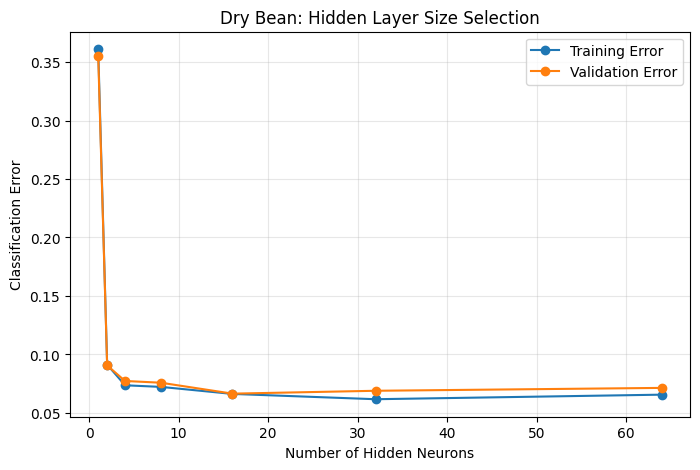

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_results_df["Hidden Units"],
    baseline_results_df["Training Error"],
    marker="o",
    label="Training Error"
)

plt.plot(
    baseline_results_df["Hidden Units"],
    baseline_results_df["Validation Error"],
    marker="o",
    label="Validation Error"
)

plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Classification Error")
plt.title("Dry Bean: Hidden Layer Size Selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score
)


def evaluate_model(model, X, y):
    model.eval()

    X_device = X.to(device)

    with torch.no_grad():
        outputs = model(X_device)
        predictions = outputs.argmax(dim=1).cpu().numpy()

    y_true = y.cpu().numpy()

    accuracy = accuracy_score(y_true, predictions)
    macro_f1 = f1_score(
        y_true,
        predictions,
        average="macro"
    )
    balanced_acc = balanced_accuracy_score(
        y_true,
        predictions
    )

    return accuracy, macro_f1, balanced_acc

In [22]:
candidate_sizes = [8, 16, 32]
seeds = [42, 123, 456]

confirmation_results = []

for hidden_units in candidate_sizes:
    for seed in seeds:

        print(
            f"Hidden units: {hidden_units}, "
            f"seed: {seed}"
        )

        torch.manual_seed(seed)

        model, history, best_epoch = train_model(
            input_size=16,
            output_size=7,
            hidden_units=hidden_units,
            train_loader=train_loader,
            X_val=X_val_tensor,
            y_val=y_val_tensor,
            learning_rate=0.001,
            max_epochs=200,
            patience=20
        )

        accuracy, macro_f1, balanced_acc = evaluate_model(
            model,
            X_val_tensor,
            y_val_tensor
        )

        confirmation_results.append({
            "Hidden Units": hidden_units,
            "Seed": seed,
            "Best Epoch": best_epoch,
            "Validation Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Balanced Accuracy": balanced_acc
        })


confirmation_df = pd.DataFrame(confirmation_results)

display(confirmation_df.round(4))

Hidden units: 8, seed: 42
Hidden units: 8, seed: 123
Hidden units: 8, seed: 456
Hidden units: 16, seed: 42
Hidden units: 16, seed: 123
Hidden units: 16, seed: 456
Hidden units: 32, seed: 42
Hidden units: 32, seed: 123
Hidden units: 32, seed: 456


,Hidden Units,Seed,Best Epoch,Validation Accuracy,Macro F1,Balanced Accuracy
0,8,42,103,0.9242,0.9337,0.9320
1,8,123,51,0.9257,0.9351,0.9345
2,8,456,44,0.9257,0.9356,0.9352
3,16,42,159,0.9335,0.9422,0.9404
4,16,123,142,0.9301,0.9387,0.9379
5,16,456,89,0.9257,0.9358,0.9347
6,32,42,106,0.9311,0.9400,0.9385
7,32,123,115,0.9291,0.9376,0.9353
8,32,456,125,0.9296,0.9387,0.9381


In [23]:
confirmation_summary = (
    confirmation_df
    .groupby("Hidden Units")
    .agg({
        "Validation Accuracy": ["mean", "std"],
        "Macro F1": ["mean", "std"],
        "Balanced Accuracy": ["mean", "std"]
    })
)

display(confirmation_summary.round(4))

Validation Accuracy         Macro F1         Balanced Accuracy  \
                            mean     std     mean     std              mean   
Hidden Units                                                                  
8                         0.9252  0.0009   0.9348  0.0010            0.9339   
16                        0.9298  0.0039   0.9389  0.0032            0.9377   
32                        0.9299  0.0010   0.9388  0.0012            0.9373   

                      
                 std  
Hidden Units          
8             0.0016  
16            0.0028  
32            0.0018

In [24]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)

baseline_test_results = []
baseline_models = {}

for seed in [42, 123, 456]:
    print(f"Training final baseline - seed {seed}")

    torch.manual_seed(seed)

    model, history, best_epoch = train_model(
        input_size=16,
        output_size=7,
        hidden_units=16,
        train_loader=train_loader,
        X_val=X_val_tensor,
        y_val=y_val_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_test_tensor,
        y_test_tensor
    )

    baseline_test_results.append({
        "Seed": seed,
        "Best Epoch": best_epoch,
        "Test Accuracy": accuracy,
        "Test Error": 1 - accuracy,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    baseline_models[seed] = model


baseline_test_df = pd.DataFrame(baseline_test_results)

display(baseline_test_df.round(4))

Training final baseline - seed 42
Training final baseline - seed 123
Training final baseline - seed 456


,Seed,Best Epoch,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,159,0.9208,0.0792,0.9349,0.9348
1,123,142,0.9227,0.0773,0.9361,0.9368
2,456,89,0.9232,0.0768,0.9365,0.9369


In [25]:
baseline_test_summary = baseline_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(baseline_test_summary.round(4))

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.9222,0.0778,0.9358,0.9362
std,0.0013,0.0013,0.0009,0.0012


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

final_baseline = baseline_models[42]

final_baseline.eval()

with torch.no_grad():
    outputs = final_baseline(X_test_tensor.to(device))
    predictions = outputs.argmax(dim=1).cpu().numpy()

y_true = y_test_tensor.numpy()

report = classification_report(
    y_true,
    predictions,
    target_names=label_encoder_dry.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
BARBUNYA,0.9391,0.9343,0.9367,198.0000
BOMBAY,1.0000,1.0000,1.0000,78.0000
CALI,0.9385,0.9347,0.9366,245.0000
DERMASON,0.9141,0.9004,0.9072,532.0000
HOROZ,0.9464,0.9498,0.9481,279.0000
SEKER,0.9570,0.9507,0.9538,304.0000
SIRA,0.8501,0.8737,0.8618,396.0000
accuracy,0.9208,0.9208,0.9208,0.9208
macro avg,0.9350,0.9348,0.9349,2032.0000
weighted avg,0.9212,0.9208,0.9209,2032.0000


In [27]:
def prepare_incremental_stage(
    X_train_scaled,
    y_train_raw,
    X_val_scaled,
    y_val_raw,
    active_classes,
    batch_size=64
):
    train_labels = y_train_raw.to_numpy()
    val_labels = y_val_raw.to_numpy()

    train_mask = np.isin(train_labels, active_classes)
    val_mask = np.isin(val_labels, active_classes)

    X_train_stage = X_train_scaled[train_mask]
    X_val_stage = X_val_scaled[val_mask]

    class_to_index = {
        class_name: i
        for i, class_name in enumerate(active_classes)
    }

    y_train_stage = np.array(
        [class_to_index[label] for label in train_labels[train_mask]]
    )

    y_val_stage = np.array(
        [class_to_index[label] for label in val_labels[val_mask]]
    )

    X_train_stage = torch.tensor(
        X_train_stage,
        dtype=torch.float32
    )

    X_val_stage = torch.tensor(
        X_val_stage,
        dtype=torch.float32
    )

    y_train_stage = torch.tensor(
        y_train_stage,
        dtype=torch.long
    )

    y_val_stage = torch.tensor(
        y_val_stage,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_stage,
        y_train_stage
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return (
        train_loader,
        X_train_stage,
        y_train_stage,
        X_val_stage,
        y_val_stage,
        class_to_index
    )

In [28]:
incremental_order_dry = (
    y_train_dry
    .value_counts()
    .sort_values()
    .index
    .tolist()
)

print("Dry Bean incremental order:")

for i, class_name in enumerate(
    incremental_order_dry,
    start=1
):
    print(f"{i}. {class_name}")

Dry Bean incremental order:
1. BOMBAY
2. BARBUNYA
3. CALI
4. HOROZ
5. SEKER
6. SIRA
7. DERMASON


In [29]:
active_classes = incremental_order_dry[:2]

(
    stage_train_loader,
    X_train_stage,
    y_train_stage,
    X_val_stage,
    y_val_stage,
    stage_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage_mapping)

print("\nTraining observations:", len(y_train_stage))
print("Validation observations:", len(y_val_stage))

Active classes: ['BOMBAY', 'BARBUNYA']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1}

Training observations: 1291
Validation observations: 277


In [30]:
torch.manual_seed(RANDOM_STATE)

stage_model, stage_history, stage_best_epoch = train_model(
    input_size=16,
    output_size=2,
    hidden_units=0,
    train_loader=stage_train_loader,
    X_val=X_val_stage,
    y_val=y_val_stage,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

train_error = stage_history["train_error"][stage_best_epoch - 1]
val_error = stage_history["val_error"][stage_best_epoch - 1]

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage_model,
    X_val_stage,
    y_val_stage
)

print("Best epoch:", stage_best_epoch)
print("Epochs run:", len(stage_history["val_loss"]))

print("\nTraining error:", round(train_error, 4))
print("Validation error:", round(val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = val_error - train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.0
Validation error: 0.0
Validation accuracy: 1.0
Macro F1: 1.0
Balanced accuracy: 1.0

Architecture status: ACCEPTABLE


In [31]:
def expand_output_layer(model, new_output_size):
    old_layer = model.network

    if not isinstance(old_layer, nn.Linear):
        raise ValueError(
            "This function currently expects a model with no hidden layer."
        )

    old_output_size = old_layer.out_features
    input_size = old_layer.in_features

    new_layer = nn.Linear(
        input_size,
        new_output_size
    )

    with torch.no_grad():
        # Preserve weights for previously learned classes
        new_layer.weight[:old_output_size] = old_layer.weight
        new_layer.bias[:old_output_size] = old_layer.bias

    model.network = new_layer

    return model.to(device)

In [32]:
def continue_training(
    model,
    train_loader,
    X_val,
    y_val,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    X_val = X_val.to(device)
    y_val = y_val.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_error": [],
        "val_error": []
    }

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()

        total_loss = 0
        total_correct = 0
        total_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y_batch)

            predictions = outputs.argmax(dim=1)

            total_correct += (
                predictions == y_batch
            ).sum().item()

            total_samples += len(y_batch)

        train_loss = total_loss / total_samples
        train_error = 1 - (
            total_correct / total_samples
        )

        model.eval()

        with torch.no_grad():
            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            ).item()

            val_predictions = val_outputs.argmax(dim=1)

            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()

            val_error = 1 - val_accuracy

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_error"].append(train_error)
        history["val_error"].append(val_error)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)

    return model, history, best_epoch

In [33]:
active_classes = incremental_order_dry[:3]

(
    stage2_train_loader,
    X_train_stage2,
    y_train_stage2,
    X_val_stage2,
    y_val_stage2,
    stage2_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage2_mapping)

print("\nTraining observations:", len(y_train_stage2))
print("Validation observations:", len(y_val_stage2))

Active classes: ['BOMBAY', 'BARBUNYA', 'CALI']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2}

Training observations: 2432
Validation observations: 521


In [34]:
stage2_model = expand_output_layer(
    stage_model,
    new_output_size=3
)

print(stage2_model)

FeedForwardNN(
  (network): Linear(in_features=16, out_features=3, bias=True)
)


In [35]:
torch.manual_seed(RANDOM_STATE)

stage2_model, stage2_history, stage2_best_epoch = continue_training(
    model=stage2_model,
    train_loader=stage2_train_loader,
    X_val=X_val_stage2,
    y_val=y_val_stage2,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

stage2_train_error = (
    stage2_history["train_error"][stage2_best_epoch - 1]
)

stage2_val_error = (
    stage2_history["val_error"][stage2_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage2_model,
    X_val_stage2,
    y_val_stage2
)

print("Best epoch:", stage2_best_epoch)
print("Epochs run:", len(stage2_history["val_loss"]))

print("\nTraining error:", round(stage2_train_error, 4))
print("Validation error:", round(stage2_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = stage2_val_error - stage2_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif stage2_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 121
Epochs run: 141

Training error: 0.0366
Validation error: 0.0461
Validation accuracy: 0.9539
Macro F1: 0.9634
Balanced accuracy: 0.9623

Architecture status: ACCEPTABLE


In [36]:
active_classes = incremental_order_dry[:4]

(
    stage3_train_loader,
    X_train_stage3,
    y_train_stage3,
    X_val_stage3,
    y_val_stage3,
    stage3_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage3_mapping)

print("\nTraining observations:", len(y_train_stage3))
print("Validation observations:", len(y_val_stage3))

Active classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2, 'HOROZ': 3}

Training observations: 3734
Validation observations: 800


In [37]:
stage3_model = expand_output_layer(
    stage2_model,
    new_output_size=4
)

print(stage3_model)

FeedForwardNN(
  (network): Linear(in_features=16, out_features=4, bias=True)
)


In [38]:
torch.manual_seed(RANDOM_STATE)

stage3_model, stage3_history, stage3_best_epoch = continue_training(
    model=stage3_model,
    train_loader=stage3_train_loader,
    X_val=X_val_stage3,
    y_val=y_val_stage3,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

stage3_train_error = (
    stage3_history["train_error"][stage3_best_epoch - 1]
)

stage3_val_error = (
    stage3_history["val_error"][stage3_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage3_model,
    X_val_stage3,
    y_val_stage3
)

print("Best epoch:", stage3_best_epoch)
print("Epochs run:", len(stage3_history["val_loss"]))

print("\nTraining error:", round(stage3_train_error, 4))
print("Validation error:", round(stage3_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = stage3_val_error - stage3_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif stage3_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 177
Epochs run: 197

Training error: 0.0367
Validation error: 0.0437
Validation accuracy: 0.9563
Macro F1: 0.9622
Balanced accuracy: 0.9613

Architecture status: ACCEPTABLE


In [39]:
active_classes = incremental_order_dry[:5]

(
    stage4_train_loader,
    X_train_stage4,
    y_train_stage4,
    X_val_stage4,
    y_val_stage4,
    stage4_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage4_mapping)

print("\nTraining observations:", len(y_train_stage4))
print("Validation observations:", len(y_val_stage4))

Active classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2, 'HOROZ': 3, 'SEKER': 4}

Training observations: 5153
Validation observations: 1104


In [40]:
stage4_model = expand_output_layer(
    stage3_model,
    new_output_size=5
)

print(stage4_model)

FeedForwardNN(
  (network): Linear(in_features=16, out_features=5, bias=True)
)


In [41]:
torch.manual_seed(RANDOM_STATE)

stage4_model, stage4_history, stage4_best_epoch = continue_training(
    model=stage4_model,
    train_loader=stage4_train_loader,
    X_val=X_val_stage4,
    y_val=y_val_stage4,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

stage4_train_error = (
    stage4_history["train_error"][stage4_best_epoch - 1]
)

stage4_val_error = (
    stage4_history["val_error"][stage4_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage4_model,
    X_val_stage4,
    y_val_stage4
)

print("Best epoch:", stage4_best_epoch)
print("Epochs run:", len(stage4_history["val_loss"]))

print("\nTraining error:", round(stage4_train_error, 4))
print("Validation error:", round(stage4_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = stage4_val_error - stage4_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif stage4_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 199
Epochs run: 200

Training error: 0.033
Validation error: 0.0408
Validation accuracy: 0.9592
Macro F1: 0.9615
Balanced accuracy: 0.9605

Architecture status: ACCEPTABLE


In [42]:
active_classes = incremental_order_dry[:6]

(
    stage5_train_loader,
    X_train_stage5,
    y_train_stage5,
    X_val_stage5,
    y_val_stage5,
    stage5_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage5_mapping)

print("\nTraining observations:", len(y_train_stage5))
print("Validation observations:", len(y_val_stage5))

Active classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER', 'SIRA']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2, 'HOROZ': 3, 'SEKER': 4, 'SIRA': 5}

Training observations: 6998
Validation observations: 1499


In [43]:
stage5_model = expand_output_layer(
    stage4_model,
    new_output_size=6
)

print(stage5_model)

FeedForwardNN(
  (network): Linear(in_features=16, out_features=6, bias=True)
)


In [44]:
torch.manual_seed(RANDOM_STATE)

stage5_model, stage5_history, stage5_best_epoch = continue_training(
    model=stage5_model,
    train_loader=stage5_train_loader,
    X_val=X_val_stage5,
    y_val=y_val_stage5,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

stage5_train_error = (
    stage5_history["train_error"][stage5_best_epoch - 1]
)

stage5_val_error = (
    stage5_history["val_error"][stage5_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage5_model,
    X_val_stage5,
    y_val_stage5
)

print("Best epoch:", stage5_best_epoch)
print("Epochs run:", len(stage5_history["val_loss"]))

print("\nTraining error:", round(stage5_train_error, 4))
print("Validation error:", round(stage5_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = stage5_val_error - stage5_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif stage5_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 198
Epochs run: 200

Training error: 0.0493
Validation error: 0.0527
Validation accuracy: 0.9473
Macro F1: 0.9507
Balanced accuracy: 0.9492

Architecture status: ACCEPTABLE


In [45]:
active_classes = incremental_order_dry[:7]

(
    stage6_train_loader,
    X_train_stage6,
    y_train_stage6,
    X_val_stage6,
    y_val_stage6,
    stage6_mapping
) = prepare_incremental_stage(
    X_train_dry_scaled,
    y_train_dry,
    X_val_dry_scaled,
    y_val_dry,
    active_classes
)

print("Active classes:", active_classes)
print("Class mapping:", stage6_mapping)

print("\nTraining observations:", len(y_train_stage6))
print("Validation observations:", len(y_val_stage6))

Active classes: ['BOMBAY', 'BARBUNYA', 'CALI', 'HOROZ', 'SEKER', 'SIRA', 'DERMASON']
Class mapping: {'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2, 'HOROZ': 3, 'SEKER': 4, 'SIRA': 5, 'DERMASON': 6}

Training observations: 9480
Validation observations: 2031


In [46]:
stage6_model = expand_output_layer(
    stage5_model,
    new_output_size=7
)

print(stage6_model)

FeedForwardNN(
  (network): Linear(in_features=16, out_features=7, bias=True)
)


In [47]:
torch.manual_seed(RANDOM_STATE)

stage6_model, stage6_history, stage6_best_epoch = continue_training(
    model=stage6_model,
    train_loader=stage6_train_loader,
    X_val=X_val_stage6,
    y_val=y_val_stage6,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

stage6_train_error = (
    stage6_history["train_error"][stage6_best_epoch - 1]
)

stage6_val_error = (
    stage6_history["val_error"][stage6_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    stage6_model,
    X_val_stage6,
    y_val_stage6
)

print("Best epoch:", stage6_best_epoch)
print("Epochs run:", len(stage6_history["val_loss"]))

print("\nTraining error:", round(stage6_train_error, 4))
print("Validation error:", round(stage6_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = stage6_val_error - stage6_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif stage6_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 196
Epochs run: 200

Training error: 0.0757
Validation error: 0.0798
Validation accuracy: 0.9202
Macro F1: 0.9307
Balanced accuracy: 0.9304

Architecture status: ACCEPTABLE


In [48]:
# Encode the Dry Bean test labels using the incremental class mapping
y_test_incremental = np.array([
    stage6_mapping[label]
    for label in y_test_dry.to_numpy()
])

y_test_incremental_tensor = torch.tensor(
    y_test_incremental,
    dtype=torch.long
)

print("Incremental class mapping:")
print(stage6_mapping)

print("\nTest observations:", len(y_test_incremental_tensor))

Incremental class mapping:
{'BOMBAY': 0, 'BARBUNYA': 1, 'CALI': 2, 'HOROZ': 3, 'SEKER': 4, 'SIRA': 5, 'DERMASON': 6}

Test observations: 2032


In [49]:
incremental_accuracy, incremental_macro_f1, incremental_balanced_acc = evaluate_model(
    stage6_model,
    X_test_tensor,
    y_test_incremental_tensor
)

print("Incremental Dry Bean test results:")
print("Accuracy:", round(incremental_accuracy, 4))
print("Classification error:", round(1 - incremental_accuracy, 4))
print("Macro F1:", round(incremental_macro_f1, 4))
print("Balanced accuracy:", round(incremental_balanced_acc, 4))

Incremental Dry Bean test results:
Accuracy: 0.9208
Classification error: 0.0792
Macro F1: 0.9342
Balanced accuracy: 0.934


In [50]:
stage6_model.eval()

with torch.no_grad():
    outputs = stage6_model(X_test_tensor.to(device))
    incremental_predictions = outputs.argmax(dim=1).cpu().numpy()

incremental_report = classification_report(
    y_test_incremental,
    incremental_predictions,
    target_names=active_classes,
    output_dict=True,
    zero_division=0
)

incremental_report_df = pd.DataFrame(
    incremental_report
).transpose()

display(incremental_report_df.round(4))

,precision,recall,f1-score,support
BOMBAY,1.0000,1.0000,1.0000,78.0000
BARBUNYA,0.9378,0.9141,0.9258,198.0000
CALI,0.9388,0.9388,0.9388,245.0000
HOROZ,0.9534,0.9534,0.9534,279.0000
SEKER,0.9416,0.9539,0.9477,304.0000
SIRA,0.8491,0.8813,0.8649,396.0000
DERMASON,0.9208,0.8966,0.9086,532.0000
accuracy,0.9208,0.9208,0.9208,0.9208
macro avg,0.9345,0.9340,0.9342,2032.0000
weighted avg,0.9213,0.9208,0.9209,2032.0000


In [51]:
dry_bean_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],
    "Accuracy": [
        baseline_test_summary.loc["mean", "Test Accuracy"],
        incremental_accuracy
    ],
    "Classification Error": [
        baseline_test_summary.loc["mean", "Test Error"],
        1 - incremental_accuracy
    ],
    "Macro F1": [
        baseline_test_summary.loc["mean", "Macro F1"],
        incremental_macro_f1
    ],
    "Balanced Accuracy": [
        baseline_test_summary.loc["mean", "Balanced Accuracy"],
        incremental_balanced_acc
    ]
})

display(dry_bean_comparison.round(4))

,Method,Accuracy,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.9222,0.0778,0.9358,0.9362
1,Incremental Class Learning,0.9208,0.0792,0.9342,0.9340


In [52]:
def run_incremental_dry_bean(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    class_order = (
        y_train_dry
        .value_counts()
        .sort_values()
        .index
        .tolist()
    )

    stage_results = []

    model = None

    for stage in range(2, len(class_order) + 1):
        active_classes = class_order[:stage]

        (
            stage_loader,
            X_train_stage,
            y_train_stage,
            X_val_stage,
            y_val_stage,
            stage_mapping
        ) = prepare_incremental_stage(
            X_train_dry_scaled,
            y_train_dry,
            X_val_dry_scaled,
            y_val_dry,
            active_classes
        )

        # Keep initialization reproducible
        torch.manual_seed(seed + stage)

        if stage == 2:
            model = FeedForwardNN(
                input_size=16,
                output_size=2,
                hidden_units=0
            ).to(device)

            model, history, best_epoch = continue_training(
                model,
                stage_loader,
                X_val_stage,
                y_val_stage,
                learning_rate=0.001,
                max_epochs=200,
                patience=20
            )

        else:
            model = expand_output_layer(
                model,
                new_output_size=stage
            )

            model, history, best_epoch = continue_training(
                model,
                stage_loader,
                X_val_stage,
                y_val_stage,
                learning_rate=0.001,
                max_epochs=200,
                patience=20
            )

        train_error = history["train_error"][best_epoch - 1]
        val_error = history["val_error"][best_epoch - 1]

        accuracy, macro_f1, balanced_acc = evaluate_model(
            model,
            X_val_stage,
            y_val_stage
        )

        stage_results.append({
            "Stage": stage - 1,
            "Classes": stage,
            "Hidden Units": 0,
            "Training Error": train_error,
            "Validation Error": val_error,
            "Macro F1": macro_f1,
            "Balanced Accuracy": balanced_acc
        })

    # Encode final test set using incremental ordering
    final_mapping = {
        class_name: i
        for i, class_name in enumerate(class_order)
    }

    y_test_incremental = np.array([
        final_mapping[label]
        for label in y_test_dry.to_numpy()
    ])

    y_test_incremental_tensor = torch.tensor(
        y_test_incremental,
        dtype=torch.long
    )

    test_accuracy, test_macro_f1, test_balanced_acc = evaluate_model(
        model,
        X_test_tensor,
        y_test_incremental_tensor
    )

    return {
        "Seed": seed,
        "Test Accuracy": test_accuracy,
        "Test Error": 1 - test_accuracy,
        "Macro F1": test_macro_f1,
        "Balanced Accuracy": test_balanced_acc
    }, pd.DataFrame(stage_results)

In [53]:
incremental_results = []
incremental_stage_runs = {}

for seed in [42, 123, 456]:
    print(f"Running incremental learning - seed {seed}")

    final_result, stage_result = run_incremental_dry_bean(seed)

    incremental_results.append(final_result)
    incremental_stage_runs[seed] = stage_result


incremental_test_df = pd.DataFrame(incremental_results)

display(incremental_test_df.round(4))

Running incremental learning - seed 42
Running incremental learning - seed 123
Running incremental learning - seed 456


,Seed,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,0.9218,0.0782,0.9351,0.9350
1,123,0.9218,0.0782,0.9351,0.9350
2,456,0.9208,0.0792,0.9342,0.9339


In [54]:
incremental_results = []
incremental_stage_runs = {}

for seed in [42, 123, 456]:
    print(f"Running incremental learning - seed {seed}")

    final_result, stage_result = run_incremental_dry_bean(seed)

    incremental_results.append(final_result)
    incremental_stage_runs[seed] = stage_result


incremental_test_df = pd.DataFrame(incremental_results)

display(incremental_test_df.round(4))

Running incremental learning - seed 42
Running incremental learning - seed 123
Running incremental learning - seed 456


,Seed,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,0.9218,0.0782,0.9351,0.9350
1,123,0.9218,0.0782,0.9351,0.9350
2,456,0.9208,0.0792,0.9342,0.9339


In [55]:
incremental_test_summary = incremental_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(incremental_test_summary.round(4))

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.9214,0.0786,0.9348,0.9347
std,0.0006,0.0006,0.0006,0.0006


In [56]:
final_dry_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],
    "Accuracy Mean": [
        baseline_test_summary.loc["mean", "Test Accuracy"],
        incremental_test_summary.loc["mean", "Test Accuracy"]
    ],
    "Accuracy Std": [
        baseline_test_summary.loc["std", "Test Accuracy"],
        incremental_test_summary.loc["std", "Test Accuracy"]
    ],
    "Macro F1 Mean": [
        baseline_test_summary.loc["mean", "Macro F1"],
        incremental_test_summary.loc["mean", "Macro F1"]
    ],
    "Balanced Accuracy Mean": [
        baseline_test_summary.loc["mean", "Balanced Accuracy"],
        incremental_test_summary.loc["mean", "Balanced Accuracy"]
    ]
})

display(final_dry_comparison.round(4))


,Method,Accuracy Mean,Accuracy Std,Macro F1 Mean,Balanced Accuracy Mean
0,Conventional NN,0.9222,0.0013,0.9358,0.9362
1,Incremental Class Learning,0.9214,0.0006,0.9348,0.9347


In [57]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

baseline_test_df.to_csv(
    RESULTS_DIR / "dry_bean_baseline_runs.csv",
    index=False
)

incremental_test_df.to_csv(
    RESULTS_DIR / "dry_bean_incremental_runs.csv",
    index=False
)

final_dry_comparison.to_csv(
    RESULTS_DIR / "dry_bean_comparison.csv",
    index=False
)

for seed, stage_df in incremental_stage_runs.items():
    stage_df.to_csv(
        RESULTS_DIR / f"dry_bean_incremental_stages_seed_{seed}.csv",
        index=False
    )

print("Dry Bean results saved.")

Dry Bean results saved.


In [58]:
dry_bean_final = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],
    "Accuracy": [
        baseline_test_summary.loc["mean", "Test Accuracy"],
        incremental_test_summary.loc["mean", "Test Accuracy"]
    ],
    "Accuracy SD": [
        baseline_test_summary.loc["std", "Test Accuracy"],
        incremental_test_summary.loc["std", "Test Accuracy"]
    ],
    "Classification Error": [
        baseline_test_summary.loc["mean", "Test Error"],
        incremental_test_summary.loc["mean", "Test Error"]
    ],
    "Macro F1": [
        baseline_test_summary.loc["mean", "Macro F1"],
        incremental_test_summary.loc["mean", "Macro F1"]
    ],
    "Balanced Accuracy": [
        baseline_test_summary.loc["mean", "Balanced Accuracy"],
        incremental_test_summary.loc["mean", "Balanced Accuracy"]
    ]
})

display(dry_bean_final.round(4))

,Method,Accuracy,Accuracy SD,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.9222,0.0013,0.0778,0.9358,0.9362
1,Incremental Class Learning,0.9214,0.0006,0.0786,0.9348,0.9347


In [59]:
X_steel = steel[steel_features].copy()
y_steel = steel["Class"].copy()

print("Predictor shape:", X_steel.shape)
print("\nClass counts:")
print(y_steel.value_counts())

print("\nExact duplicate rows:")
print(steel[steel_features + ["Class"]].duplicated().sum())

Predictor shape: (1941, 27)

Class counts:
Class
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
Name: count, dtype: int64

Exact duplicate rows:
0


In [60]:
X_train_steel, X_temp_steel, y_train_steel, y_temp_steel = train_test_split(
    X_steel,
    y_steel,
    test_size=0.30,
    stratify=y_steel,
    random_state=RANDOM_STATE
)

X_val_steel, X_test_steel, y_val_steel, y_test_steel = train_test_split(
    X_temp_steel,
    y_temp_steel,
    test_size=0.50,
    stratify=y_temp_steel,
    random_state=RANDOM_STATE
)

print("Train:", X_train_steel.shape)
print("Validation:", X_val_steel.shape)
print("Test:", X_test_steel.shape)

print("\nTraining class counts:")
print(y_train_steel.value_counts())

print("\nIncremental order:")
print(
    y_train_steel.value_counts()
    .sort_values()
)

Train: (1358, 27)
Validation: (291, 27)
Test: (292, 27)

Training class counts:
Class
Other_Faults    471
Bumps           281
K_Scatch        274
Z_Scratch       133
Pastry          111
Stains           50
Dirtiness        38
Name: count, dtype: int64

Incremental order:
Class
Dirtiness        38
Stains           50
Pastry          111
Z_Scratch       133
K_Scatch        274
Bumps           281
Other_Faults    471
Name: count, dtype: int64


In [61]:
scaler_steel = StandardScaler()

X_train_steel_scaled = scaler_steel.fit_transform(X_train_steel)
X_val_steel_scaled = scaler_steel.transform(X_val_steel)
X_test_steel_scaled = scaler_steel.transform(X_test_steel)

label_encoder_steel = LabelEncoder()

y_train_steel_encoded = label_encoder_steel.fit_transform(y_train_steel)
y_val_steel_encoded = label_encoder_steel.transform(y_val_steel)
y_test_steel_encoded = label_encoder_steel.transform(y_test_steel)

print("Encoded classes:")
for i, class_name in enumerate(label_encoder_steel.classes_):
    print(f"{i}: {class_name}")

print(
    "\nScaled training mean:",
    round(X_train_steel_scaled.mean(), 6)
)

print(
    "Scaled training average std:",
    round(X_train_steel_scaled.std(axis=0).mean(), 6)
)

Encoded classes:
0: Bumps
1: Dirtiness
2: K_Scatch
3: Other_Faults
4: Pastry
5: Stains
6: Z_Scratch

Scaled training mean: -0.0
Scaled training average std: 1.0


In [62]:
X_train_steel_tensor = torch.tensor(
    X_train_steel_scaled,
    dtype=torch.float32
)

X_val_steel_tensor = torch.tensor(
    X_val_steel_scaled,
    dtype=torch.float32
)

X_test_steel_tensor = torch.tensor(
    X_test_steel_scaled,
    dtype=torch.float32
)

y_train_steel_tensor = torch.tensor(
    y_train_steel_encoded,
    dtype=torch.long
)

y_val_steel_tensor = torch.tensor(
    y_val_steel_encoded,
    dtype=torch.long
)

y_test_steel_tensor = torch.tensor(
    y_test_steel_encoded,
    dtype=torch.long
)

steel_train_dataset = TensorDataset(
    X_train_steel_tensor,
    y_train_steel_tensor
)

steel_train_loader = DataLoader(
    steel_train_dataset,
    batch_size=64,
    shuffle=True
)

print("Training batches:", len(steel_train_loader))

print("\nTensor shapes:")
print(X_train_steel_tensor.shape, y_train_steel_tensor.shape)
print(X_val_steel_tensor.shape, y_val_steel_tensor.shape)
print(X_test_steel_tensor.shape, y_test_steel_tensor.shape)

Training batches: 22

Tensor shapes:
torch.Size([1358, 27]) torch.Size([1358])
torch.Size([291, 27]) torch.Size([291])
torch.Size([292, 27]) torch.Size([292])


In [63]:
steel_hidden_sizes = [1, 2, 4, 8, 16, 32, 64]

steel_baseline_results = []

for hidden_units in steel_hidden_sizes:
    print(f"Training with {hidden_units} hidden units...")

    torch.manual_seed(RANDOM_STATE)

    model, history, best_epoch = train_model(
        input_size=27,
        output_size=7,
        hidden_units=hidden_units,
        train_loader=steel_train_loader,
        X_val=X_val_steel_tensor,
        y_val=y_val_steel_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]
    val_loss = history["val_loss"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_val_steel_tensor,
        y_val_steel_tensor
    )

    steel_baseline_results.append({
        "Hidden Units": hidden_units,
        "Best Epoch": best_epoch,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Validation Loss": val_loss,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })


steel_baseline_results_df = pd.DataFrame(
    steel_baseline_results
)

display(
    steel_baseline_results_df.round(4)
)

Training with 1 hidden units...
Training with 2 hidden units...
Training with 4 hidden units...
Training with 8 hidden units...
Training with 16 hidden units...
Training with 32 hidden units...
Training with 64 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss,Macro F1,Balanced Accuracy
0,1,199,0.4742,0.4845,1.2589,0.2135,0.2677
1,2,176,0.3667,0.3814,1.1221,0.4858,0.5144
2,4,194,0.3181,0.3368,0.9253,0.6290,0.6099
3,8,138,0.2474,0.2887,0.7863,0.7450,0.7100
4,16,107,0.2150,0.2680,0.7321,0.7683,0.7513
5,32,56,0.2121,0.2612,0.7170,0.7715,0.7514
6,64,44,0.2032,0.2543,0.6950,0.7766,0.7482


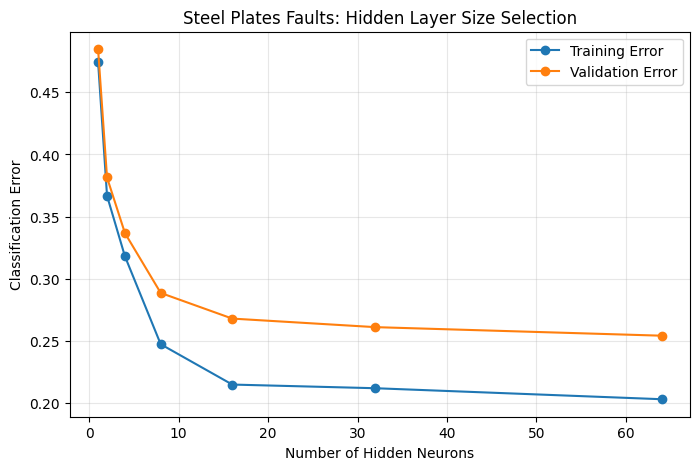

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    steel_baseline_results_df["Hidden Units"],
    steel_baseline_results_df["Training Error"],
    marker="o",
    label="Training Error"
)

plt.plot(
    steel_baseline_results_df["Hidden Units"],
    steel_baseline_results_df["Validation Error"],
    marker="o",
    label="Validation Error"
)

plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Classification Error")
plt.title("Steel Plates Faults: Hidden Layer Size Selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [65]:
extra_sizes = [128, 256]

extra_results = []

for hidden_units in extra_sizes:
    print(f"Training with {hidden_units} hidden units...")

    torch.manual_seed(RANDOM_STATE)

    model, history, best_epoch = train_model(
        input_size=27,
        output_size=7,
        hidden_units=hidden_units,
        train_loader=steel_train_loader,
        X_val=X_val_steel_tensor,
        y_val=y_val_steel_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]
    val_loss = history["val_loss"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_val_steel_tensor,
        y_val_steel_tensor
    )

    extra_results.append({
        "Hidden Units": hidden_units,
        "Best Epoch": best_epoch,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Validation Loss": val_loss,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

extra_results_df = pd.DataFrame(extra_results)

steel_baseline_results_df = pd.concat(
    [steel_baseline_results_df, extra_results_df],
    ignore_index=True
)

display(
    steel_baseline_results_df
    .sort_values("Hidden Units")
    .round(4)
)

Training with 128 hidden units...
Training with 256 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss,Macro F1,Balanced Accuracy
0,1,199,0.4742,0.4845,1.2589,0.2135,0.2677
1,2,176,0.3667,0.3814,1.1221,0.4858,0.5144
2,4,194,0.3181,0.3368,0.9253,0.6290,0.6099
3,8,138,0.2474,0.2887,0.7863,0.7450,0.7100
4,16,107,0.2150,0.2680,0.7321,0.7683,0.7513
5,32,56,0.2121,0.2612,0.7170,0.7715,0.7514
6,64,44,0.2032,0.2543,0.6950,0.7766,0.7482
7,128,49,0.1657,0.2509,0.6793,0.7805,0.7541
8,256,30,0.1760,0.2440,0.6695,0.7858,0.7569


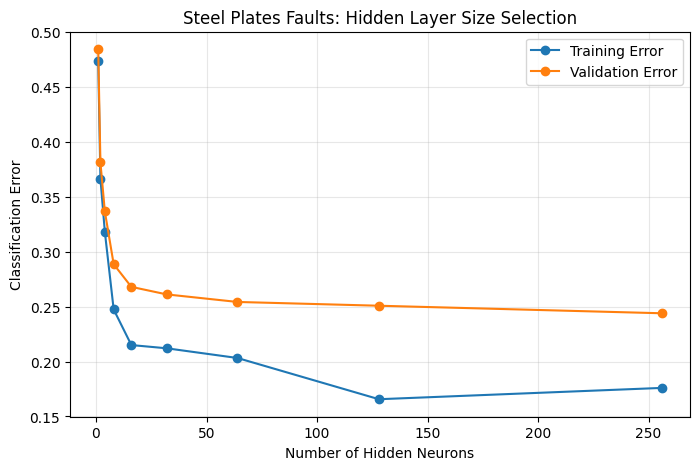

In [66]:
steel_baseline_results_df = (
    steel_baseline_results_df
    .sort_values("Hidden Units")
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))

plt.plot(
    steel_baseline_results_df["Hidden Units"],
    steel_baseline_results_df["Training Error"],
    marker="o",
    label="Training Error"
)

plt.plot(
    steel_baseline_results_df["Hidden Units"],
    steel_baseline_results_df["Validation Error"],
    marker="o",
    label="Validation Error"
)

plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Classification Error")
plt.title("Steel Plates Faults: Hidden Layer Size Selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [67]:
hidden_units = 512

print(f"Training with {hidden_units} hidden units...")

torch.manual_seed(RANDOM_STATE)

model, history, best_epoch = train_model(
    input_size=27,
    output_size=7,
    hidden_units=hidden_units,
    train_loader=steel_train_loader,
    X_val=X_val_steel_tensor,
    y_val=y_val_steel_tensor,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

train_error = history["train_error"][best_epoch - 1]
val_error = history["val_error"][best_epoch - 1]
val_loss = history["val_loss"][best_epoch - 1]

accuracy, macro_f1, balanced_acc = evaluate_model(
    model,
    X_val_steel_tensor,
    y_val_steel_tensor
)

result_512 = pd.DataFrame([{
    "Hidden Units": hidden_units,
    "Best Epoch": best_epoch,
    "Training Error": train_error,
    "Validation Error": val_error,
    "Validation Loss": val_loss,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}])

steel_baseline_results_df = pd.concat(
    [steel_baseline_results_df, result_512],
    ignore_index=True
)

steel_baseline_results_df = (
    steel_baseline_results_df
    .sort_values("Hidden Units")
    .reset_index(drop=True)
)

display(steel_baseline_results_df.round(4))

Training with 512 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss,Macro F1,Balanced Accuracy
0,1,199,0.4742,0.4845,1.2589,0.2135,0.2677
1,2,176,0.3667,0.3814,1.1221,0.4858,0.5144
2,4,194,0.3181,0.3368,0.9253,0.6290,0.6099
3,8,138,0.2474,0.2887,0.7863,0.7450,0.7100
4,16,107,0.2150,0.2680,0.7321,0.7683,0.7513
5,32,56,0.2121,0.2612,0.7170,0.7715,0.7514
6,64,44,0.2032,0.2543,0.6950,0.7766,0.7482
7,128,49,0.1657,0.2509,0.6793,0.7805,0.7541
8,256,30,0.1760,0.2440,0.6695,0.7858,0.7569
9,512,29,0.1620,0.2371,0.6800,0.7939,0.7652


In [68]:
steel_candidate_sizes = [128, 256, 512]
seeds = [42, 123, 456]

steel_confirmation_results = []

for hidden_units in steel_candidate_sizes:
    for seed in seeds:
        print(
            f"Hidden units: {hidden_units}, "
            f"seed: {seed}"
        )

        torch.manual_seed(seed)

        model, history, best_epoch = train_model(
            input_size=27,
            output_size=7,
            hidden_units=hidden_units,
            train_loader=steel_train_loader,
            X_val=X_val_steel_tensor,
            y_val=y_val_steel_tensor,
            learning_rate=0.001,
            max_epochs=200,
            patience=20
        )

        train_error = history["train_error"][best_epoch - 1]
        val_error = history["val_error"][best_epoch - 1]

        accuracy, macro_f1, balanced_acc = evaluate_model(
            model,
            X_val_steel_tensor,
            y_val_steel_tensor
        )

        steel_confirmation_results.append({
            "Hidden Units": hidden_units,
            "Seed": seed,
            "Best Epoch": best_epoch,
            "Training Error": train_error,
            "Validation Error": val_error,
            "Validation Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Balanced Accuracy": balanced_acc
        })


steel_confirmation_df = pd.DataFrame(
    steel_confirmation_results
)

display(steel_confirmation_df.round(4))

Hidden units: 128, seed: 42
Hidden units: 128, seed: 123
Hidden units: 128, seed: 456
Hidden units: 256, seed: 42
Hidden units: 256, seed: 123
Hidden units: 256, seed: 456
Hidden units: 512, seed: 42
Hidden units: 512, seed: 123
Hidden units: 512, seed: 456


,Hidden Units,Seed,Best Epoch,Training Error,Validation Error,Validation Accuracy,Macro F1,Balanced Accuracy
0,128,42,49,0.1657,0.2509,0.7491,0.7805,0.7541
1,128,123,31,0.1973,0.2577,0.7423,0.7729,0.7530
2,128,456,47,0.1782,0.2234,0.7766,0.8021,0.7775
3,256,42,30,0.1760,0.2440,0.7560,0.7858,0.7569
4,256,123,25,0.1907,0.2474,0.7526,0.7832,0.7655
5,256,456,40,0.1627,0.2405,0.7595,0.7860,0.7589
6,512,42,29,0.1620,0.2371,0.7629,0.7939,0.7652
7,512,123,32,0.1495,0.2371,0.7629,0.7955,0.7745
8,512,456,18,0.1885,0.2440,0.7560,0.7883,0.7680


In [69]:
steel_confirmation_summary = (
    steel_confirmation_df
    .groupby("Hidden Units")
    .agg({
        "Validation Accuracy": ["mean", "std"],
        "Macro F1": ["mean", "std"],
        "Balanced Accuracy": ["mean", "std"],
        "Validation Error": ["mean", "std"]
    })
)

display(steel_confirmation_summary.round(4))

Validation Accuracy         Macro F1         Balanced Accuracy  \
                            mean     std     mean     std              mean   
Hidden Units                                                                  
128                       0.7560  0.0182   0.7852  0.0151            0.7616   
256                       0.7560  0.0034   0.7850  0.0016            0.7604   
512                       0.7606  0.0040   0.7926  0.0037            0.7692   

                     Validation Error          
                 std             mean     std  
Hidden Units                                   
128           0.0138           0.2440  0.0182  
256           0.0045           0.2440  0.0034  
512           0.0048           0.2394  0.0040

In [70]:
steel_baseline_test_results = []
steel_baseline_models = {}

for seed in [42, 123, 456]:
    print(f"Training final Steel baseline - seed {seed}")

    torch.manual_seed(seed)

    model, history, best_epoch = train_model(
        input_size=27,
        output_size=7,
        hidden_units=512,
        train_loader=steel_train_loader,
        X_val=X_val_steel_tensor,
        y_val=y_val_steel_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_test_steel_tensor,
        y_test_steel_tensor
    )

    steel_baseline_test_results.append({
        "Seed": seed,
        "Best Epoch": best_epoch,
        "Test Accuracy": accuracy,
        "Test Error": 1 - accuracy,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    steel_baseline_models[seed] = model


steel_baseline_test_df = pd.DataFrame(
    steel_baseline_test_results
)

display(steel_baseline_test_df.round(4))

Training final Steel baseline - seed 42
Training final Steel baseline - seed 123
Training final Steel baseline - seed 456


,Seed,Best Epoch,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,29,0.7500,0.2500,0.7631,0.7492
1,123,32,0.7603,0.2397,0.7655,0.7621
2,456,18,0.7432,0.2568,0.7565,0.7436


In [71]:
steel_baseline_test_summary = steel_baseline_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(steel_baseline_test_summary.round(4))

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.7511,0.2489,0.7617,0.7516
std,0.0086,0.0086,0.0047,0.0095


In [72]:
steel_final_baseline = steel_baseline_models[42]

steel_final_baseline.eval()

with torch.no_grad():
    outputs = steel_final_baseline(
        X_test_steel_tensor.to(device)
    )

    steel_predictions = (
        outputs.argmax(dim=1)
        .cpu()
        .numpy()
    )

steel_y_true = y_test_steel_tensor.numpy()

steel_report = classification_report(
    steel_y_true,
    steel_predictions,
    target_names=label_encoder_steel.classes_,
    output_dict=True,
    zero_division=0
)

steel_report_df = pd.DataFrame(
    steel_report
).transpose()

display(steel_report_df.round(4))

,precision,recall,f1-score,support
Bumps,0.6667,0.6885,0.6774,61.00
Dirtiness,1.0000,0.7500,0.8571,8.00
K_Scatch,0.9630,0.8814,0.9204,59.00
Other_Faults,0.6759,0.7228,0.6986,101.00
Pastry,0.5714,0.5217,0.5455,23.00
Stains,0.6923,0.8182,0.7500,11.00
Z_Scratch,0.9259,0.8621,0.8929,29.00
accuracy,0.7500,0.7500,0.7500,0.75
macro avg,0.7850,0.7492,0.7631,292.00
weighted avg,0.7581,0.7500,0.7525,292.00


In [73]:
steel_baseline_test_df.to_csv(
    RESULTS_DIR / "steel_baseline_runs.csv",
    index=False
)

steel_confirmation_df.to_csv(
    RESULTS_DIR / "steel_baseline_architecture_confirmation.csv",
    index=False
)

print("Steel baseline results saved.")

Steel baseline results saved.


In [74]:
incremental_order_steel = (
    y_train_steel
    .value_counts()
    .sort_values()
    .index
    .tolist()
)

print("Steel incremental order:")

for i, class_name in enumerate(
    incremental_order_steel,
    start=1
):
    print(f"{i}. {class_name}")

Steel incremental order:
1. Dirtiness
2. Stains
3. Pastry
4. Z_Scratch
5. K_Scatch
6. Bumps
7. Other_Faults


In [75]:
steel_active_classes = incremental_order_steel[:2]

(
    steel_stage1_loader,
    X_train_steel_stage1,
    y_train_steel_stage1,
    X_val_steel_stage1,
    y_val_steel_stage1,
    steel_stage1_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Class mapping:", steel_stage1_mapping)

print("\nTraining observations:", len(y_train_steel_stage1))
print("Validation observations:", len(y_val_steel_stage1))

Active classes: ['Dirtiness', 'Stains']
Class mapping: {'Dirtiness': 0, 'Stains': 1}

Training observations: 88
Validation observations: 20


In [76]:
torch.manual_seed(RANDOM_STATE)

steel_stage1_model, steel_stage1_history, steel_stage1_best_epoch = train_model(
    input_size=27,
    output_size=2,
    hidden_units=0,
    train_loader=steel_stage1_loader,
    X_val=X_val_steel_stage1,
    y_val=y_val_steel_stage1,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

steel_stage1_train_error = (
    steel_stage1_history["train_error"][steel_stage1_best_epoch - 1]
)

steel_stage1_val_error = (
    steel_stage1_history["val_error"][steel_stage1_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage1_model,
    X_val_steel_stage1,
    y_val_steel_stage1
)

print("Best epoch:", steel_stage1_best_epoch)
print("Epochs run:", len(steel_stage1_history["val_loss"]))

print("\nTraining error:", round(steel_stage1_train_error, 4))
print("Validation error:", round(steel_stage1_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = steel_stage1_val_error - steel_stage1_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif steel_stage1_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.0
Validation error: 0.0
Validation accuracy: 1.0
Macro F1: 1.0
Balanced accuracy: 1.0

Architecture status: ACCEPTABLE


In [77]:
steel_stage_results = [{
    "Stage": 1,
    "Classes": 2,
    "Active Classes": "Dirtiness, Stains",
    "Hidden Units": 0,
    "Training Error": steel_stage1_train_error,
    "Validation Error": steel_stage1_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}]

In [78]:
steel_active_classes = incremental_order_steel[:3]

(
    steel_stage2_loader,
    X_train_steel_stage2,
    y_train_steel_stage2,
    X_val_steel_stage2,
    y_val_steel_stage2,
    steel_stage2_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Class mapping:", steel_stage2_mapping)

print("\nTraining observations:", len(y_train_steel_stage2))
print("Validation observations:", len(y_val_steel_stage2))

Active classes: ['Dirtiness', 'Stains', 'Pastry']
Class mapping: {'Dirtiness': 0, 'Stains': 1, 'Pastry': 2}

Training observations: 199
Validation observations: 44


In [79]:
torch.manual_seed(RANDOM_STATE + 3)

steel_stage2_model = expand_output_layer(
    steel_stage1_model,
    new_output_size=3
)

print(steel_stage2_model)

FeedForwardNN(
  (network): Linear(in_features=27, out_features=3, bias=True)
)


In [80]:
steel_stage2_model, steel_stage2_history, steel_stage2_best_epoch = continue_training(
    model=steel_stage2_model,
    train_loader=steel_stage2_loader,
    X_val=X_val_steel_stage2,
    y_val=y_val_steel_stage2,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

steel_stage2_train_error = (
    steel_stage2_history["train_error"][steel_stage2_best_epoch - 1]
)

steel_stage2_val_error = (
    steel_stage2_history["val_error"][steel_stage2_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage2_model,
    X_val_steel_stage2,
    y_val_steel_stage2
)

print("Best epoch:", steel_stage2_best_epoch)
print("Epochs run:", len(steel_stage2_history["val_loss"]))

print("\nTraining error:", round(steel_stage2_train_error, 4))
print("Validation error:", round(steel_stage2_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

gap = steel_stage2_val_error - steel_stage2_train_error

if gap >= 0.03:
    status = "OVERFITTING"
elif steel_stage2_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.0452
Validation error: 0.0909
Validation accuracy: 0.9091
Macro F1: 0.89
Balanced accuracy: 0.875

Architecture status: OVERFITTING


In [81]:
steel_stage_results.append({
    "Stage": 2,
    "Classes": 3,
    "Active Classes": ", ".join(steel_active_classes),
    "Hidden Units": 0,
    "Training Error": steel_stage2_train_error,
    "Validation Error": steel_stage2_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
})

In [82]:
steel_active_classes = incremental_order_steel[:4]

(
    steel_stage3_loader,
    X_train_steel_stage3,
    y_train_steel_stage3,
    X_val_steel_stage3,
    y_val_steel_stage3,
    steel_stage3_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Class mapping:", steel_stage3_mapping)

print("\nTraining observations:", len(y_train_steel_stage3))
print("Validation observations:", len(y_val_steel_stage3))

Active classes: ['Dirtiness', 'Stains', 'Pastry', 'Z_Scratch']
Class mapping: {'Dirtiness': 0, 'Stains': 1, 'Pastry': 2, 'Z_Scratch': 3}

Training observations: 332
Validation observations: 72


In [83]:
torch.manual_seed(RANDOM_STATE + 4)

steel_stage3_model = expand_output_layer(
    steel_stage2_model,
    new_output_size=4
)

print(steel_stage3_model)

FeedForwardNN(
  (network): Linear(in_features=27, out_features=4, bias=True)
)


In [84]:
steel_stage3_model, steel_stage3_history, steel_stage3_best_epoch = continue_training(
    model=steel_stage3_model,
    train_loader=steel_stage3_loader,
    X_val=X_val_steel_stage3,
    y_val=y_val_steel_stage3,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

steel_stage3_train_error = (
    steel_stage3_history["train_error"][steel_stage3_best_epoch - 1]
)

steel_stage3_val_error = (
    steel_stage3_history["val_error"][steel_stage3_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage3_model,
    X_val_steel_stage3,
    y_val_steel_stage3
)

print("Best epoch:", steel_stage3_best_epoch)
print("Epochs run:", len(steel_stage3_history["val_loss"]))

print("\nTraining error:", round(steel_stage3_train_error, 4))
print("Validation error:", round(steel_stage3_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

if steel_stage3_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "UNDERFITTING / CAPACITY INCREASE NEEDED"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.0663
Validation error: 0.0972
Validation accuracy: 0.9028
Macro F1: 0.8683
Balanced accuracy: 0.8519

Architecture status: ACCEPTABLE


In [85]:
steel_stage_results.append({
    "Stage": 3,
    "Classes": 4,
    "Active Classes": ", ".join(steel_active_classes),
    "Hidden Units": 0,
    "Training Error": steel_stage3_train_error,
    "Validation Error": steel_stage3_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
})

In [86]:
steel_active_classes = incremental_order_steel[:5]

(
    steel_stage4_loader,
    X_train_steel_stage4,
    y_train_steel_stage4,
    X_val_steel_stage4,
    y_val_steel_stage4,
    steel_stage4_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Class mapping:", steel_stage4_mapping)

print("\nTraining observations:", len(y_train_steel_stage4))
print("Validation observations:", len(y_val_steel_stage4))

Active classes: ['Dirtiness', 'Stains', 'Pastry', 'Z_Scratch', 'K_Scatch']
Class mapping: {'Dirtiness': 0, 'Stains': 1, 'Pastry': 2, 'Z_Scratch': 3, 'K_Scatch': 4}

Training observations: 606
Validation observations: 130


In [87]:
torch.manual_seed(RANDOM_STATE + 5)

steel_stage4_model = expand_output_layer(
    steel_stage3_model,
    new_output_size=5
)

print(steel_stage4_model)

FeedForwardNN(
  (network): Linear(in_features=27, out_features=5, bias=True)
)


In [88]:
steel_stage4_model, steel_stage4_history, steel_stage4_best_epoch = continue_training(
    model=steel_stage4_model,
    train_loader=steel_stage4_loader,
    X_val=X_val_steel_stage4,
    y_val=y_val_steel_stage4,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

steel_stage4_train_error = (
    steel_stage4_history["train_error"][steel_stage4_best_epoch - 1]
)

steel_stage4_val_error = (
    steel_stage4_history["val_error"][steel_stage4_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage4_model,
    X_val_steel_stage4,
    y_val_steel_stage4
)

print("Best epoch:", steel_stage4_best_epoch)
print("Epochs run:", len(steel_stage4_history["val_loss"]))

print("\nTraining error:", round(steel_stage4_train_error, 4))
print("Validation error:", round(steel_stage4_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

if steel_stage4_val_error <= 0.10:
    status = "ACCEPTABLE"
else:
    status = "CAPACITY INCREASE NEEDED"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.0446
Validation error: 0.1
Validation accuracy: 0.9
Macro F1: 0.8551
Balanced accuracy: 0.8473

Architecture status: CAPACITY INCREASE NEEDED


In [89]:
print("Exact validation error:", repr(steel_stage4_val_error))

Exact validation error: 0.10000002384185791


In [90]:
if steel_stage4_val_error <= 0.1001:
    status = "ACCEPTABLE"
else:
    status = "CAPACITY INCREASE NEEDED"

print("Architecture status:", status)

Architecture status: ACCEPTABLE


In [91]:
steel_stage_results.append({
    "Stage": 4,
    "Classes": 5,
    "Active Classes": ", ".join(steel_active_classes),
    "Hidden Units": 0,
    "Training Error": steel_stage4_train_error,
    "Validation Error": steel_stage4_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
})

In [92]:
steel_active_classes = incremental_order_steel[:6]

(
    steel_stage5_loader,
    X_train_steel_stage5,
    y_train_steel_stage5,
    X_val_steel_stage5,
    y_val_steel_stage5,
    steel_stage5_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Class mapping:", steel_stage5_mapping)

print("\nTraining observations:", len(y_train_steel_stage5))
print("Validation observations:", len(y_val_steel_stage5))

Active classes: ['Dirtiness', 'Stains', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Bumps']
Class mapping: {'Dirtiness': 0, 'Stains': 1, 'Pastry': 2, 'Z_Scratch': 3, 'K_Scatch': 4, 'Bumps': 5}

Training observations: 887
Validation observations: 190


In [93]:
torch.manual_seed(RANDOM_STATE + 6)

steel_stage5_model = expand_output_layer(
    steel_stage4_model,
    new_output_size=6
)

print(steel_stage5_model)

FeedForwardNN(
  (network): Linear(in_features=27, out_features=6, bias=True)
)


In [94]:
steel_stage5_model, steel_stage5_history, steel_stage5_best_epoch = continue_training(
    model=steel_stage5_model,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

steel_stage5_train_error = (
    steel_stage5_history["train_error"][steel_stage5_best_epoch - 1]
)

steel_stage5_val_error = (
    steel_stage5_history["val_error"][steel_stage5_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage5_model,
    X_val_steel_stage5,
    y_val_steel_stage5
)

print("Best epoch:", steel_stage5_best_epoch)
print("Epochs run:", len(steel_stage5_history["val_loss"]))

print("\nTraining error:", round(steel_stage5_train_error, 4))
print("Validation error:", round(steel_stage5_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

if steel_stage5_val_error <= 0.1001:
    status = "ACCEPTABLE"
else:
    status = "CAPACITY CHECK NEEDED"

print("\nArchitecture status:", status)

Best epoch: 200
Epochs run: 200

Training error: 0.1161
Validation error: 0.1526
Validation accuracy: 0.8474
Macro F1: 0.825
Balanced accuracy: 0.8135

Architecture status: CAPACITY CHECK NEEDED


In [95]:
steel_stage5_model, steel_stage5_history_extra, steel_stage5_best_epoch_extra = continue_training(
    model=steel_stage5_model,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

steel_stage5_train_error_extra = (
    steel_stage5_history_extra["train_error"][
        steel_stage5_best_epoch_extra - 1
    ]
)

steel_stage5_val_error_extra = (
    steel_stage5_history_extra["val_error"][
        steel_stage5_best_epoch_extra - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage5_model,
    X_val_steel_stage5,
    y_val_steel_stage5
)

print("Best epoch in extra training:", steel_stage5_best_epoch_extra)
print("Epochs run:", len(steel_stage5_history_extra["val_loss"]))

print("\nTraining error:", round(steel_stage5_train_error_extra, 4))
print("Validation error:", round(steel_stage5_val_error_extra, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch in extra training: 6
Epochs run: 36

Training error: 0.1161
Validation error: 0.1526
Validation accuracy: 0.8474
Macro F1: 0.825
Balanced accuracy: 0.8135


In [96]:
torch.manual_seed(RANDOM_STATE)

steel_stage5_hidden1, hidden1_history, hidden1_best_epoch = train_model(
    input_size=27,
    output_size=6,
    hidden_units=1,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

hidden1_train_error = (
    hidden1_history["train_error"][hidden1_best_epoch - 1]
)

hidden1_val_error = (
    hidden1_history["val_error"][hidden1_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage5_hidden1,
    X_val_steel_stage5,
    y_val_steel_stage5
)

print("Best epoch:", hidden1_best_epoch)
print("Epochs run:", len(hidden1_history["val_loss"]))

print("\nTraining error:", round(hidden1_train_error, 4))
print("Validation error:", round(hidden1_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 299
Epochs run: 300

Training error: 0.3901
Validation error: 0.4211
Validation accuracy: 0.5789
Macro F1: 0.2821
Balanced accuracy: 0.3265


In [97]:
def expand_hidden_layer(model):
    old_layers = model.network

    old_input = old_layers[0]
    old_output = old_layers[2]

    input_size = old_input.in_features
    old_hidden = old_input.out_features
    output_size = old_output.out_features

    new_hidden = old_hidden + 1

    new_input = nn.Linear(
        input_size,
        new_hidden
    )

    new_output = nn.Linear(
        new_hidden,
        output_size
    )

    with torch.no_grad():
        # Preserve existing hidden neurons
        new_input.weight[:old_hidden] = old_input.weight
        new_input.bias[:old_hidden] = old_input.bias

        # Preserve existing output connections
        new_output.weight[:, :old_hidden] = old_output.weight
        new_output.bias[:] = old_output.bias

    model.network = nn.Sequential(
        new_input,
        nn.ReLU(),
        new_output
    )

    model.hidden_units = new_hidden

    return model.to(device)

In [98]:
torch.manual_seed(RANDOM_STATE + 2)

steel_stage5_hidden2 = expand_hidden_layer(
    steel_stage5_hidden1
)

print(steel_stage5_hidden2)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=2, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2, out_features=6, bias=True)
  )
)


In [99]:
steel_stage5_hidden2, hidden2_history, hidden2_best_epoch = continue_training(
    model=steel_stage5_hidden2,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

hidden2_train_error = (
    hidden2_history["train_error"][hidden2_best_epoch - 1]
)

hidden2_val_error = (
    hidden2_history["val_error"][hidden2_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage5_hidden2,
    X_val_steel_stage5,
    y_val_steel_stage5
)

print("Best epoch:", hidden2_best_epoch)
print("Epochs run:", len(hidden2_history["val_loss"]))

print("\nTraining error:", round(hidden2_train_error, 4))
print("Validation error:", round(hidden2_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 158
Epochs run: 188

Training error: 0.2458
Validation error: 0.2632
Validation accuracy: 0.7368
Macro F1: 0.4874
Balanced accuracy: 0.5149


In [100]:
import copy

steel_hidden_growth_results = [
    {
        "Hidden Units": 1,
        "Training Error": hidden1_train_error,
        "Validation Error": hidden1_val_error,
        "Macro F1": 0.2821,
        "Balanced Accuracy": 0.3265
    },
    {
        "Hidden Units": 2,
        "Training Error": hidden2_train_error,
        "Validation Error": hidden2_val_error,
        "Macro F1": 0.4874,
        "Balanced Accuracy": 0.5149
    }
]

current_model = steel_stage5_hidden2

best_growth_model = copy.deepcopy(current_model)
best_growth_val_error = hidden2_val_error

for hidden_units in range(3, 21):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    # Add exactly one hidden neuron
    current_model = expand_hidden_layer(current_model)

    current_model, history, best_epoch = continue_training(
        model=current_model,
        train_loader=steel_stage5_loader,
        X_val=X_val_steel_stage5,
        y_val=y_val_steel_stage5,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_model,
        X_val_steel_stage5,
        y_val_steel_stage5
    )

    steel_hidden_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))

    if val_error < best_growth_val_error:
        best_growth_val_error = val_error
        best_growth_model = copy.deepcopy(current_model)

    # Once the hidden network matches or improves on the
    # stagnated no-hidden model, stop increasing capacity
    if val_error <= steel_stage5_val_error_extra:
        print("\nHidden-layer performance is now acceptable.")
        break


Testing 3 hidden neurons...
Training error: 0.1736
Validation error: 0.2316
Macro F1: 0.5767
Balanced accuracy: 0.5854

Testing 4 hidden neurons...
Training error: 0.1353
Validation error: 0.2053
Macro F1: 0.7125
Balanced accuracy: 0.687

Testing 5 hidden neurons...
Training error: 0.1082
Validation error: 0.1789
Macro F1: 0.7803
Balanced accuracy: 0.7621

Testing 6 hidden neurons...
Training error: 0.1071
Validation error: 0.1737
Macro F1: 0.7915
Balanced accuracy: 0.7772

Testing 7 hidden neurons...
Training error: 0.1037
Validation error: 0.1789
Macro F1: 0.7793
Balanced accuracy: 0.7703

Testing 8 hidden neurons...
Training error: 0.1037
Validation error: 0.1737
Macro F1: 0.7915
Balanced accuracy: 0.7772

Testing 9 hidden neurons...
Training error: 0.1048
Validation error: 0.1737
Macro F1: 0.7915
Balanced accuracy: 0.7772

Testing 10 hidden neurons...
Training error: 0.0755
Validation error: 0.1316
Macro F1: 0.8449
Balanced accuracy: 0.8476

Hidden-layer performance is now accepta

In [101]:
steel_hidden_growth_df = pd.DataFrame(
    steel_hidden_growth_results
)

display(steel_hidden_growth_df.round(4))

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,1,0.3901,0.4211,0.2821,0.3265
1,2,0.2458,0.2632,0.4874,0.5149
2,3,0.1736,0.2316,0.5767,0.5854
3,4,0.1353,0.2053,0.7125,0.6870
4,5,0.1082,0.1789,0.7803,0.7621
5,6,0.1071,0.1737,0.7915,0.7772
6,7,0.1037,0.1789,0.7793,0.7703
7,8,0.1037,0.1737,0.7915,0.7772
8,9,0.1048,0.1737,0.7915,0.7772
9,10,0.0755,0.1316,0.8449,0.8476


In [102]:
for hidden_units in range(11, 16):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    current_model = expand_hidden_layer(current_model)

    current_model, history, best_epoch = continue_training(
        model=current_model,
        train_loader=steel_stage5_loader,
        X_val=X_val_steel_stage5,
        y_val=y_val_steel_stage5,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_model,
        X_val_steel_stage5,
        y_val_steel_stage5
    )

    steel_hidden_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))


Testing 11 hidden neurons...
Training error: 0.0744
Validation error: 0.1316
Macro F1: 0.8412
Balanced accuracy: 0.8507

Testing 12 hidden neurons...
Training error: 0.0767
Validation error: 0.1211
Macro F1: 0.8505
Balanced accuracy: 0.8564

Testing 13 hidden neurons...
Training error: 0.0744
Validation error: 0.1316
Macro F1: 0.8449
Balanced accuracy: 0.8507

Testing 14 hidden neurons...
Training error: 0.0722
Validation error: 0.1263
Macro F1: 0.8462
Balanced accuracy: 0.8536

Testing 15 hidden neurons...
Training error: 0.071
Validation error: 0.1263
Macro F1: 0.8462
Balanced accuracy: 0.8536


In [103]:
steel_hidden_growth_df = pd.DataFrame(
    steel_hidden_growth_results
)

display(steel_hidden_growth_df.round(4))

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,1,0.3901,0.4211,0.2821,0.3265
1,2,0.2458,0.2632,0.4874,0.5149
2,3,0.1736,0.2316,0.5767,0.5854
3,4,0.1353,0.2053,0.7125,0.6870
4,5,0.1082,0.1789,0.7803,0.7621
5,6,0.1071,0.1737,0.7915,0.7772
6,7,0.1037,0.1789,0.7793,0.7703
7,8,0.1037,0.1737,0.7915,0.7772
8,9,0.1048,0.1737,0.7915,0.7772
9,10,0.0755,0.1316,0.8449,0.8476


In [104]:
steel_hidden_growth_df.to_csv(
    RESULTS_DIR / "steel_hidden_growth_six_classes.csv",
    index=False
)

print("Steel hidden-growth results saved.")

Steel hidden-growth results saved.


In [105]:
steel_stage5_selected = copy.deepcopy(best_growth_model)

print("Starting hidden units:",
    steel_stage5_selected.hidden_units)

# Grow 10 -> 11
torch.manual_seed(RANDOM_STATE + 11)

steel_stage5_selected = expand_hidden_layer(
    steel_stage5_selected
)

steel_stage5_selected, _, _ = continue_training(
    model=steel_stage5_selected,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

# Grow 11 -> 12
torch.manual_seed(RANDOM_STATE + 12)

steel_stage5_selected = expand_hidden_layer(
    steel_stage5_selected
)

steel_stage5_selected, _, _ = continue_training(
    model=steel_stage5_selected,
    train_loader=steel_stage5_loader,
    X_val=X_val_steel_stage5,
    y_val=y_val_steel_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

print(steel_stage5_selected)

Starting hidden units: 10
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=6, bias=True)
  )
)


In [106]:
def expand_hidden_model_output(model, new_output_size):
    old_layers = model.network

    hidden_layer = old_layers[0]
    old_output = old_layers[2]

    hidden_units = hidden_layer.out_features
    old_output_size = old_output.out_features

    new_output = nn.Linear(
        hidden_units,
        new_output_size
    )

    with torch.no_grad():
        # Preserve connections for existing classes
        new_output.weight[:old_output_size] = old_output.weight
        new_output.bias[:old_output_size] = old_output.bias

    model.network[2] = new_output

    return model.to(device)

In [107]:
steel_active_classes = incremental_order_steel[:7]

(
    steel_stage6_loader,
    X_train_steel_stage6,
    y_train_steel_stage6,
    X_val_steel_stage6,
    y_val_steel_stage6,
    steel_stage6_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Training observations:", len(y_train_steel_stage6))
print("Validation observations:", len(y_val_steel_stage6))

Active classes: ['Dirtiness', 'Stains', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Bumps', 'Other_Faults']
Training observations: 1358
Validation observations: 291


In [108]:
steel_active_classes = incremental_order_steel[:7]

(
    steel_stage6_loader,
    X_train_steel_stage6,
    y_train_steel_stage6,
    X_val_steel_stage6,
    y_val_steel_stage6,
    steel_stage6_mapping
) = prepare_incremental_stage(
    X_train_steel_scaled,
    y_train_steel,
    X_val_steel_scaled,
    y_val_steel,
    steel_active_classes
)

print("Active classes:", steel_active_classes)
print("Training observations:", len(y_train_steel_stage6))
print("Validation observations:", len(y_val_steel_stage6))

Active classes: ['Dirtiness', 'Stains', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Bumps', 'Other_Faults']
Training observations: 1358
Validation observations: 291


In [109]:
torch.manual_seed(RANDOM_STATE + 7)

steel_stage6_model = expand_hidden_model_output(
    steel_stage5_selected,
    new_output_size=7
)

print(steel_stage6_model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=7, bias=True)
  )
)


In [110]:
steel_stage6_model, steel_stage6_history, steel_stage6_best_epoch = continue_training(
    model=steel_stage6_model,
    train_loader=steel_stage6_loader,
    X_val=X_val_steel_stage6,
    y_val=y_val_steel_stage6,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

steel_stage6_train_error = (
    steel_stage6_history["train_error"][
        steel_stage6_best_epoch - 1
    ]
)

steel_stage6_val_error = (
    steel_stage6_history["val_error"][
        steel_stage6_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    steel_stage6_model,
    X_val_steel_stage6,
    y_val_steel_stage6
)

print("Best epoch:", steel_stage6_best_epoch)
print("Epochs run:", len(steel_stage6_history["val_loss"]))

print("\nTraining error:", round(steel_stage6_train_error, 4))
print("Validation error:", round(steel_stage6_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 102
Epochs run: 132

Training error: 0.2128
Validation error: 0.2749
Validation accuracy: 0.7251
Macro F1: 0.7403
Balanced accuracy: 0.7025


In [111]:
steel_final_growth_results = [{
    "Hidden Units": 12,
    "Training Error": steel_stage6_train_error,
    "Validation Error": steel_stage6_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}]

current_final_model = steel_stage6_model
best_final_model = copy.deepcopy(current_final_model)
best_final_val_error = steel_stage6_val_error

for hidden_units in range(13, 26):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    current_final_model = expand_hidden_layer(
        current_final_model
    )

    current_final_model, history, best_epoch = continue_training(
        model=current_final_model,
        train_loader=steel_stage6_loader,
        X_val=X_val_steel_stage6,
        y_val=y_val_steel_stage6,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_final_model,
        X_val_steel_stage6,
        y_val_steel_stage6
    )

    steel_final_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))

    if val_error < best_final_val_error:
        best_final_val_error = val_error
        best_final_model = copy.deepcopy(
            current_final_model
        )


Testing 13 hidden neurons...
Training error: 0.2194
Validation error: 0.2646
Macro F1: 0.7492
Balanced accuracy: 0.7122

Testing 14 hidden neurons...
Training error: 0.2135
Validation error: 0.2646
Macro F1: 0.7602
Balanced accuracy: 0.7267

Testing 15 hidden neurons...
Training error: 0.2121
Validation error: 0.2715
Macro F1: 0.7532
Balanced accuracy: 0.7184

Testing 16 hidden neurons...
Training error: 0.1981
Validation error: 0.268
Macro F1: 0.7528
Balanced accuracy: 0.7306

Testing 17 hidden neurons...
Training error: 0.2032
Validation error: 0.2749
Macro F1: 0.7514
Balanced accuracy: 0.7196

Testing 18 hidden neurons...
Training error: 0.1966
Validation error: 0.2749
Macro F1: 0.7543
Balanced accuracy: 0.7241

Testing 19 hidden neurons...
Training error: 0.1973
Validation error: 0.2646
Macro F1: 0.7519
Balanced accuracy: 0.7248

Testing 20 hidden neurons...
Training error: 0.1981
Validation error: 0.2612
Macro F1: 0.7557
Balanced accuracy: 0.7308

Testing 21 hidden neurons...
Tra

In [112]:
steel_final_growth_df = pd.DataFrame(
    steel_final_growth_results
)

display(steel_final_growth_df.round(4))

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,12,0.2128,0.2749,0.7403,0.7025
1,13,0.2194,0.2646,0.7492,0.7122
2,14,0.2135,0.2646,0.7602,0.7267
3,15,0.2121,0.2715,0.7532,0.7184
4,16,0.1981,0.2680,0.7528,0.7306
5,17,0.2032,0.2749,0.7514,0.7196
6,18,0.1966,0.2749,0.7543,0.7241
7,19,0.1973,0.2646,0.7519,0.7248
8,20,0.1981,0.2612,0.7557,0.7308
9,21,0.1922,0.2474,0.7653,0.7439


In [113]:
steel_final_growth_df.to_csv(
    RESULTS_DIR / "steel_hidden_growth_all_classes.csv",
    index=False
)

print("Steel final hidden-growth results saved.")

Steel final hidden-growth results saved.


In [114]:
print("Selected hidden units:", best_final_model.hidden_units)
print(best_final_model)

Selected hidden units: 21
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=27, out_features=21, bias=True)
    (1): ReLU()
    (2): Linear(in_features=21, out_features=7, bias=True)
  )
)


In [115]:
steel_final_mapping = {
    class_name: i
    for i, class_name in enumerate(incremental_order_steel)
}

y_test_steel_incremental = np.array([
    steel_final_mapping[label]
    for label in y_test_steel.to_numpy()
])

y_test_steel_incremental_tensor = torch.tensor(
    y_test_steel_incremental,
    dtype=torch.long
)

print("Incremental mapping:")
print(steel_final_mapping)

print("\nTest observations:",
    len(y_test_steel_incremental_tensor))

Incremental mapping:
{'Dirtiness': 0, 'Stains': 1, 'Pastry': 2, 'Z_Scratch': 3, 'K_Scatch': 4, 'Bumps': 5, 'Other_Faults': 6}

Test observations: 292


In [116]:
steel_incremental_accuracy, steel_incremental_macro_f1, steel_incremental_balanced_acc = evaluate_model(
    best_final_model,
    X_test_steel_tensor,
    y_test_steel_incremental_tensor
)

print("Steel incremental test results:")
print(
    "Accuracy:",
    round(steel_incremental_accuracy, 4)
)
print(
    "Classification error:",
    round(1 - steel_incremental_accuracy, 4)
)
print(
    "Macro F1:",
    round(steel_incremental_macro_f1, 4)
)
print(
    "Balanced accuracy:",
    round(steel_incremental_balanced_acc, 4)
)

Steel incremental test results:
Accuracy: 0.774
Classification error: 0.226
Macro F1: 0.7591
Balanced accuracy: 0.7651


In [117]:
best_final_model.eval()

with torch.no_grad():
    outputs = best_final_model(
        X_test_steel_tensor.to(device)
    )

    steel_incremental_predictions = (
        outputs.argmax(dim=1)
        .cpu()
        .numpy()
    )

steel_incremental_report = classification_report(
    y_test_steel_incremental,
    steel_incremental_predictions,
    target_names=incremental_order_steel,
    output_dict=True,
    zero_division=0
)

steel_incremental_report_df = pd.DataFrame(
    steel_incremental_report
).transpose()

display(
    steel_incremental_report_df.round(4)
)

,precision,recall,f1-score,support
Dirtiness,0.6000,0.7500,0.6667,8.000
Stains,0.8333,0.9091,0.8696,11.000
Pastry,0.5263,0.4348,0.4762,23.000
Z_Scratch,0.9615,0.8621,0.9091,29.000
K_Scatch,0.9655,0.9492,0.9573,59.000
Bumps,0.7000,0.6885,0.6942,61.000
Other_Faults,0.7196,0.7624,0.7404,101.000
accuracy,0.7740,0.7740,0.7740,0.774
macro avg,0.7580,0.7651,0.7591,292.000
weighted avg,0.7750,0.7740,0.7734,292.000


In [118]:
steel_seed42_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],
    "Accuracy": [
        0.7500,
        steel_incremental_accuracy
    ],
    "Classification Error": [
        0.2500,
        1 - steel_incremental_accuracy
    ],
    "Macro F1": [
        0.7631,
        steel_incremental_macro_f1
    ],
    "Balanced Accuracy": [
        0.7492,
        steel_incremental_balanced_acc
    ]
})

display(
    steel_seed42_comparison.round(4)
)

,Method,Accuracy,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.750,0.250,0.7631,0.7492
1,Incremental Class Learning,0.774,0.226,0.7591,0.7651


In [119]:
steel_seed42_comparison.to_csv(
    RESULTS_DIR / "steel_seed42_comparison.csv",
    index=False
)

steel_incremental_report_df.to_csv(
    RESULTS_DIR / "steel_incremental_class_report_seed42.csv"
)

print("Steel seed-42 incremental results saved.")

Steel seed-42 incremental results saved.


In [120]:
def run_steel_incremental(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    class_order = (
        y_train_steel
        .value_counts()
        .sort_values()
        .index
        .tolist()
    )

    # ---------------------------------------------------
    # Stages 1-4: 2, 3, 4 and 5 classes, no hidden layer
    # ---------------------------------------------------
    model = None

    for n_classes in range(2, 6):
        active_classes = class_order[:n_classes]

        (
            stage_loader,
            X_train_stage,
            y_train_stage,
            X_val_stage,
            y_val_stage,
            stage_mapping
        ) = prepare_incremental_stage(
            X_train_steel_scaled,
            y_train_steel,
            X_val_steel_scaled,
            y_val_steel,
            active_classes
        )

        torch.manual_seed(seed + n_classes)

        if n_classes == 2:
            model = FeedForwardNN(
                input_size=27,
                output_size=2,
                hidden_units=0
            ).to(device)

        else:
            model = expand_output_layer(
                model,
                new_output_size=n_classes
            )

        model, _, _ = continue_training(
            model=model,
            train_loader=stage_loader,
            X_val=X_val_stage,
            y_val=y_val_stage,
            learning_rate=0.001,
            max_epochs=200,
            patience=20
        )

    # ---------------------------------------------------
    # Stage 5: six classes
    # Hidden layer grows from 1 to selected size of 12
    # ---------------------------------------------------
    active_classes = class_order[:6]

    (
        stage6_loader,
        X_train_stage6,
        y_train_stage6,
        X_val_stage6,
        y_val_stage6,
        stage6_mapping
    ) = prepare_incremental_stage(
        X_train_steel_scaled,
        y_train_steel,
        X_val_steel_scaled,
        y_val_steel,
        active_classes
    )

    torch.manual_seed(seed + 100)

    model = FeedForwardNN(
        input_size=27,
        output_size=6,
        hidden_units=1
    ).to(device)

    model, _, _ = continue_training(
        model=model,
        train_loader=stage6_loader,
        X_val=X_val_stage6,
        y_val=y_val_stage6,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    for hidden_units in range(2, 13):
        torch.manual_seed(seed + 100 + hidden_units)

        model = expand_hidden_layer(model)

        model, _, _ = continue_training(
            model=model,
            train_loader=stage6_loader,
            X_val=X_val_stage6,
            y_val=y_val_stage6,
            learning_rate=0.001,
            max_epochs=300,
            patience=30
        )

    # ---------------------------------------------------
    # Final stage: all seven classes
    # ---------------------------------------------------
    active_classes = class_order[:7]

    (
        final_loader,
        X_train_final,
        y_train_final,
        X_val_final,
        y_val_final,
        final_mapping
    ) = prepare_incremental_stage(
        X_train_steel_scaled,
        y_train_steel,
        X_val_steel_scaled,
        y_val_steel,
        active_classes
    )

    torch.manual_seed(seed + 200)

    model = expand_hidden_model_output(
        model,
        new_output_size=7
    )

    model, _, _ = continue_training(
        model=model,
        train_loader=final_loader,
        X_val=X_val_final,
        y_val=y_val_final,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    # Grow 12 -> 21 hidden neurons
    for hidden_units in range(13, 22):
        torch.manual_seed(seed + 200 + hidden_units)

        model = expand_hidden_layer(model)

        model, _, _ = continue_training(
            model=model,
            train_loader=final_loader,
            X_val=X_val_final,
            y_val=y_val_final,
            learning_rate=0.001,
            max_epochs=300,
            patience=30
        )

    # ---------------------------------------------------
    # Final untouched test evaluation
    # ---------------------------------------------------
    test_mapping = {
        class_name: i
        for i, class_name in enumerate(class_order)
    }

    y_test_incremental = np.array([
        test_mapping[label]
        for label in y_test_steel.to_numpy()
    ])

    y_test_incremental_tensor = torch.tensor(
        y_test_incremental,
        dtype=torch.long
    )

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_test_steel_tensor,
        y_test_incremental_tensor
    )

    return {
        "Seed": seed,
        "Final Hidden Units": model.hidden_units,
        "Test Accuracy": accuracy,
        "Test Error": 1 - accuracy,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    }

In [121]:
steel_incremental_results = []

for seed in [42, 123, 456]:
    print(f"Running Steel incremental learning - seed {seed}")

    result = run_steel_incremental(seed)
    steel_incremental_results.append(result)


steel_incremental_test_df = pd.DataFrame(
    steel_incremental_results
)

display(steel_incremental_test_df.round(4))

Running Steel incremental learning - seed 42
Running Steel incremental learning - seed 123
Running Steel incremental learning - seed 456


,Seed,Final Hidden Units,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,21,0.7363,0.2637,0.7516,0.7456
1,123,21,0.7534,0.2466,0.7602,0.7497
2,456,21,0.7226,0.2774,0.7389,0.7226


In [122]:
steel_incremental_test_summary = steel_incremental_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(
    steel_incremental_test_summary.round(4)
)

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.7374,0.2626,0.7502,0.7393
std,0.0154,0.0154,0.0107,0.0146


In [123]:
steel_final_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],

    "Accuracy": [
        steel_baseline_test_summary.loc["mean", "Test Accuracy"],
        steel_incremental_test_summary.loc["mean", "Test Accuracy"]
    ],

    "Accuracy SD": [
        steel_baseline_test_summary.loc["std", "Test Accuracy"],
        steel_incremental_test_summary.loc["std", "Test Accuracy"]
    ],

    "Classification Error": [
        steel_baseline_test_summary.loc["mean", "Test Error"],
        steel_incremental_test_summary.loc["mean", "Test Error"]
    ],

    "Macro F1": [
        steel_baseline_test_summary.loc["mean", "Macro F1"],
        steel_incremental_test_summary.loc["mean", "Macro F1"]
    ],

    "Balanced Accuracy": [
        steel_baseline_test_summary.loc["mean", "Balanced Accuracy"],
        steel_incremental_test_summary.loc["mean", "Balanced Accuracy"]
    ]
})

display(steel_final_comparison.round(4))

,Method,Accuracy,Accuracy SD,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.7511,0.0086,0.2489,0.7617,0.7516
1,Incremental Class Learning,0.7374,0.0154,0.2626,0.7502,0.7393


In [124]:
steel_incremental_test_df.to_csv(
    RESULTS_DIR / "steel_incremental_runs.csv",
    index=False
)

steel_final_comparison.to_csv(
    RESULTS_DIR / "steel_final_comparison.csv",
    index=False
)

print("Final Steel results saved.")

Final Steel results saved.


In [125]:
print("Training duplicates:", landsat_train.duplicated().sum())
print("Test duplicates:", landsat_test.duplicated().sum())

train_unique = landsat_train.drop_duplicates()
test_unique = landsat_test.drop_duplicates()

overlap = pd.merge(
    train_unique,
    test_unique,
    how="inner"
)

print("Exact rows appearing in both train and test:", len(overlap))

print("\nTraining class counts:")
print(landsat_train["Class"].value_counts().sort_index())

print("\nTest class counts:")
print(landsat_test["Class"].value_counts().sort_index())

Training duplicates: 0
Test duplicates: 0
Exact rows appearing in both train and test: 0

Training class counts:
Class
1    1072
2     479
3     961
4     415
5     470
7    1038
Name: count, dtype: int64

Test class counts:
Class
1    461
2    224
3    397
4    211
5    237
7    470
Name: count, dtype: int64


In [126]:
X_landsat = landsat_train.drop(columns="Class")
y_landsat = landsat_train["Class"]

X_test_landsat = landsat_test.drop(columns="Class")
y_test_landsat = landsat_test["Class"]

X_train_landsat, X_val_landsat, y_train_landsat, y_val_landsat = train_test_split(
    X_landsat,
    y_landsat,
    test_size=0.20,
    stratify=y_landsat,
    random_state=RANDOM_STATE
)

print("Train:", X_train_landsat.shape)
print("Validation:", X_val_landsat.shape)
print("Official test:", X_test_landsat.shape)

print("\nTraining class counts:")
print(y_train_landsat.value_counts().sort_index())

print("\nIncremental order:")
print(
    y_train_landsat
    .value_counts()
    .sort_values()
)

Train: (3548, 36)
Validation: (887, 36)
Official test: (2000, 36)

Training class counts:
Class
1    858
2    383
3    769
4    332
5    376
7    830
Name: count, dtype: int64

Incremental order:
Class
4    332
5    376
2    383
3    769
7    830
1    858
Name: count, dtype: int64


In [127]:
scaler_landsat = StandardScaler()

X_train_landsat_scaled = scaler_landsat.fit_transform(
    X_train_landsat
)

X_val_landsat_scaled = scaler_landsat.transform(
    X_val_landsat
)

X_test_landsat_scaled = scaler_landsat.transform(
    X_test_landsat
)

label_encoder_landsat = LabelEncoder()

y_train_landsat_encoded = label_encoder_landsat.fit_transform(
    y_train_landsat
)

y_val_landsat_encoded = label_encoder_landsat.transform(
    y_val_landsat
)

y_test_landsat_encoded = label_encoder_landsat.transform(
    y_test_landsat
)

print("Encoded classes:")

for i, class_name in enumerate(label_encoder_landsat.classes_):
    print(f"{i}: {class_name}")

print(
    "\nScaled training mean:",
    round(X_train_landsat_scaled.mean(), 6)
)

print(
    "Scaled training average std:",
    round(
        X_train_landsat_scaled.std(axis=0).mean(),
        6
    )
)

Encoded classes:
0: 1
1: 2
2: 3
3: 4
4: 5
5: 7

Scaled training mean: 0.0
Scaled training average std: 1.0


In [128]:
X_train_landsat_tensor = torch.tensor(
    X_train_landsat_scaled,
    dtype=torch.float32
)

X_val_landsat_tensor = torch.tensor(
    X_val_landsat_scaled,
    dtype=torch.float32
)

X_test_landsat_tensor = torch.tensor(
    X_test_landsat_scaled,
    dtype=torch.float32
)

y_train_landsat_tensor = torch.tensor(
    y_train_landsat_encoded,
    dtype=torch.long
)

y_val_landsat_tensor = torch.tensor(
    y_val_landsat_encoded,
    dtype=torch.long
)

y_test_landsat_tensor = torch.tensor(
    y_test_landsat_encoded,
    dtype=torch.long
)

landsat_train_dataset = TensorDataset(
    X_train_landsat_tensor,
    y_train_landsat_tensor
)

landsat_train_loader = DataLoader(
    landsat_train_dataset,
    batch_size=64,
    shuffle=True
)

print("Training batches:", len(landsat_train_loader))

print("\nTensor shapes:")
print(
    X_train_landsat_tensor.shape,
    y_train_landsat_tensor.shape
)
print(
    X_val_landsat_tensor.shape,
    y_val_landsat_tensor.shape
)
print(
    X_test_landsat_tensor.shape,
    y_test_landsat_tensor.shape
)

Training batches: 56

Tensor shapes:
torch.Size([3548, 36]) torch.Size([3548])
torch.Size([887, 36]) torch.Size([887])
torch.Size([2000, 36]) torch.Size([2000])


In [129]:
landsat_hidden_sizes = [1, 2, 4, 8, 16, 32, 64, 128]

landsat_baseline_results = []

for hidden_units in landsat_hidden_sizes:
    print(f"Training with {hidden_units} hidden units...")

    torch.manual_seed(RANDOM_STATE)

    model, history, best_epoch = train_model(
        input_size=36,
        output_size=6,
        hidden_units=hidden_units,
        train_loader=landsat_train_loader,
        X_val=X_val_landsat_tensor,
        y_val=y_val_landsat_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]
    val_loss = history["val_loss"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_val_landsat_tensor,
        y_val_landsat_tensor
    )

    landsat_baseline_results.append({
        "Hidden Units": hidden_units,
        "Best Epoch": best_epoch,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Validation Loss": val_loss,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })


landsat_baseline_results_df = pd.DataFrame(
    landsat_baseline_results
)

display(
    landsat_baseline_results_df.round(4)
)

Training with 1 hidden units...
Training with 2 hidden units...
Training with 4 hidden units...
Training with 8 hidden units...
Training with 16 hidden units...
Training with 32 hidden units...
Training with 64 hidden units...
Training with 128 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss,Macro F1,Balanced Accuracy
0,1,197,0.3574,0.3675,1.0281,0.3737,0.4558
1,2,199,0.1933,0.2120,0.5636,0.6882,0.7024
2,4,198,0.1294,0.1432,0.3575,0.8089,0.8069
3,8,127,0.1026,0.1274,0.3341,0.8336,0.8295
4,16,156,0.0789,0.1082,0.3059,0.8607,0.8591
5,32,93,0.0736,0.1105,0.2794,0.8597,0.8556
6,64,103,0.0544,0.1071,0.2648,0.8670,0.8667
7,128,63,0.0558,0.1037,0.2565,0.8719,0.8704


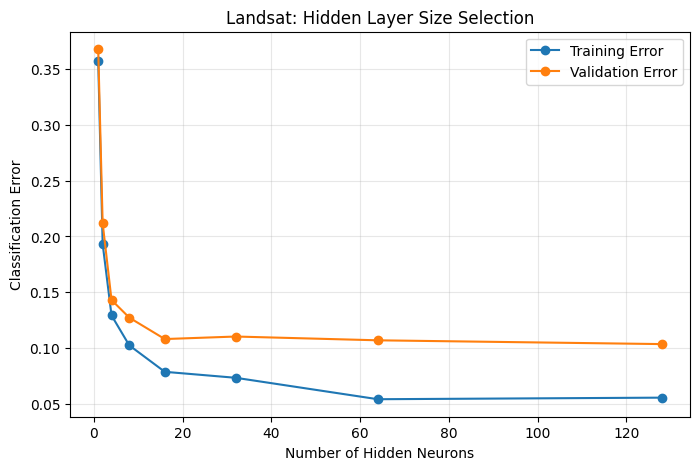

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(
    landsat_baseline_results_df["Hidden Units"],
    landsat_baseline_results_df["Training Error"],
    marker="o",
    label="Training Error"
)

plt.plot(
    landsat_baseline_results_df["Hidden Units"],
    landsat_baseline_results_df["Validation Error"],
    marker="o",
    label="Validation Error"
)

plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Classification Error")
plt.title("Landsat: Hidden Layer Size Selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [131]:
hidden_units = 256

print(f"Training with {hidden_units} hidden units...")

torch.manual_seed(RANDOM_STATE)

model, history, best_epoch = train_model(
    input_size=36,
    output_size=6,
    hidden_units=hidden_units,
    train_loader=landsat_train_loader,
    X_val=X_val_landsat_tensor,
    y_val=y_val_landsat_tensor,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

train_error = history["train_error"][best_epoch - 1]
val_error = history["val_error"][best_epoch - 1]
val_loss = history["val_loss"][best_epoch - 1]

accuracy, macro_f1, balanced_acc = evaluate_model(
    model,
    X_val_landsat_tensor,
    y_val_landsat_tensor
)

result_256 = pd.DataFrame([{
    "Hidden Units": hidden_units,
    "Best Epoch": best_epoch,
    "Training Error": train_error,
    "Validation Error": val_error,
    "Validation Loss": val_loss,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}])

landsat_baseline_results_df = pd.concat(
    [landsat_baseline_results_df, result_256],
    ignore_index=True
)

landsat_baseline_results_df = (
    landsat_baseline_results_df
    .sort_values("Hidden Units")
    .reset_index(drop=True)
)

display(landsat_baseline_results_df.round(4))

Training with 256 hidden units...


,Hidden Units,Best Epoch,Training Error,Validation Error,Validation Loss,Macro F1,Balanced Accuracy
0,1,197,0.3574,0.3675,1.0281,0.3737,0.4558
1,2,199,0.1933,0.2120,0.5636,0.6882,0.7024
2,4,198,0.1294,0.1432,0.3575,0.8089,0.8069
3,8,127,0.1026,0.1274,0.3341,0.8336,0.8295
4,16,156,0.0789,0.1082,0.3059,0.8607,0.8591
5,32,93,0.0736,0.1105,0.2794,0.8597,0.8556
6,64,103,0.0544,0.1071,0.2648,0.8670,0.8667
7,128,63,0.0558,0.1037,0.2565,0.8719,0.8704
8,256,46,0.0567,0.0958,0.2562,0.8788,0.8758


In [132]:
landsat_candidate_sizes = [64, 128, 256]
seeds = [42, 123, 456]

landsat_confirmation_results = []

for hidden_units in landsat_candidate_sizes:
    for seed in seeds:
        print(
            f"Hidden units: {hidden_units}, "
            f"seed: {seed}"
        )

        torch.manual_seed(seed)

        model, history, best_epoch = train_model(
            input_size=36,
            output_size=6,
            hidden_units=hidden_units,
            train_loader=landsat_train_loader,
            X_val=X_val_landsat_tensor,
            y_val=y_val_landsat_tensor,
            learning_rate=0.001,
            max_epochs=200,
            patience=20
        )

        train_error = history["train_error"][best_epoch - 1]
        val_error = history["val_error"][best_epoch - 1]

        accuracy, macro_f1, balanced_acc = evaluate_model(
            model,
            X_val_landsat_tensor,
            y_val_landsat_tensor
        )

        landsat_confirmation_results.append({
            "Hidden Units": hidden_units,
            "Seed": seed,
            "Best Epoch": best_epoch,
            "Training Error": train_error,
            "Validation Error": val_error,
            "Validation Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Balanced Accuracy": balanced_acc
        })


landsat_confirmation_df = pd.DataFrame(
    landsat_confirmation_results
)

display(landsat_confirmation_df.round(4))

Hidden units: 64, seed: 42
Hidden units: 64, seed: 123
Hidden units: 64, seed: 456
Hidden units: 128, seed: 42
Hidden units: 128, seed: 123
Hidden units: 128, seed: 456
Hidden units: 256, seed: 42
Hidden units: 256, seed: 123
Hidden units: 256, seed: 456


,Hidden Units,Seed,Best Epoch,Training Error,Validation Error,Validation Accuracy,Macro F1,Balanced Accuracy
0,64,42,103,0.0544,0.1071,0.8929,0.8670,0.8667
1,64,123,98,0.0581,0.1071,0.8929,0.8699,0.8699
2,64,456,83,0.0657,0.1037,0.8963,0.8660,0.8621
3,128,42,63,0.0558,0.1037,0.8963,0.8719,0.8704
4,128,123,79,0.0485,0.0981,0.9019,0.8805,0.8800
5,128,456,63,0.0600,0.0981,0.9019,0.8758,0.8700
6,256,42,46,0.0567,0.0958,0.9042,0.8788,0.8758
7,256,123,48,0.0555,0.1015,0.8985,0.8732,0.8722
8,256,456,50,0.0527,0.0970,0.9030,0.8819,0.8804


In [133]:
landsat_confirmation_summary = (
    landsat_confirmation_df
    .groupby("Hidden Units")
    .agg({
        "Validation Accuracy": ["mean", "std"],
        "Macro F1": ["mean", "std"],
        "Balanced Accuracy": ["mean", "std"],
        "Validation Error": ["mean", "std"]
    })
)

display(landsat_confirmation_summary.round(4))

Validation Accuracy         Macro F1         Balanced Accuracy  \
                            mean     std     mean     std              mean   
Hidden Units                                                                  
64                        0.8940  0.0020   0.8677  0.0020            0.8662   
128                       0.9000  0.0033   0.8761  0.0043            0.8734   
256                       0.9019  0.0030   0.8780  0.0044            0.8761   

                     Validation Error          
                 std             mean     std  
Hidden Units                                   
64            0.0039           0.1060  0.0020  
128           0.0057           0.1000  0.0033  
256           0.0041           0.0981  0.0030

In [134]:
landsat_baseline_test_results = []
landsat_baseline_models = {}

for seed in [42, 123, 456]:
    print(f"Training final Landsat baseline - seed {seed}")

    torch.manual_seed(seed)

    model, history, best_epoch = train_model(
        input_size=36,
        output_size=6,
        hidden_units=256,
        train_loader=landsat_train_loader,
        X_val=X_val_landsat_tensor,
        y_val=y_val_landsat_tensor,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_test_landsat_tensor,
        y_test_landsat_tensor
    )

    landsat_baseline_test_results.append({
        "Seed": seed,
        "Best Epoch": best_epoch,
        "Test Accuracy": accuracy,
        "Test Error": 1 - accuracy,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    landsat_baseline_models[seed] = model


landsat_baseline_test_df = pd.DataFrame(
    landsat_baseline_test_results
)

display(landsat_baseline_test_df.round(4))

Training final Landsat baseline - seed 42
Training final Landsat baseline - seed 123
Training final Landsat baseline - seed 456


,Seed,Best Epoch,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,46,0.903,0.097,0.8879,0.8855
1,123,48,0.905,0.095,0.8911,0.8901
2,456,50,0.899,0.101,0.8874,0.8855


In [135]:
landsat_baseline_test_summary = landsat_baseline_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(
    landsat_baseline_test_summary.round(4)
)

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.9023,0.0977,0.8888,0.8870
std,0.0031,0.0031,0.0020,0.0026


In [136]:
landsat_final_baseline = landsat_baseline_models[42]

landsat_final_baseline.eval()

with torch.no_grad():
    outputs = landsat_final_baseline(
        X_test_landsat_tensor.to(device)
    )

    landsat_predictions = (
        outputs.argmax(dim=1)
        .cpu()
        .numpy()
    )

landsat_y_true = y_test_landsat_tensor.numpy()

landsat_report = classification_report(
    landsat_y_true,
    landsat_predictions,
    target_names=[
        str(x)
        for x in label_encoder_landsat.classes_
    ],
    output_dict=True,
    zero_division=0
)

landsat_report_df = pd.DataFrame(
    landsat_report
).transpose()

display(landsat_report_df.round(4))

,precision,recall,f1-score,support
1,0.9828,0.9935,0.9881,461.000
2,0.9690,0.9777,0.9733,224.000
3,0.8889,0.9471,0.9171,397.000
4,0.7600,0.6303,0.6891,211.000
5,0.8912,0.8987,0.8950,237.000
7,0.8641,0.8660,0.8650,470.000
accuracy,0.9030,0.9030,0.9030,0.903
macro avg,0.8927,0.8855,0.8879,2000.000
weighted avg,0.9004,0.9030,0.9009,2000.000


In [137]:
landsat_baseline_test_df.to_csv(
    RESULTS_DIR / "landsat_baseline_runs.csv",
    index=False
)

landsat_confirmation_df.to_csv(
    RESULTS_DIR / "landsat_baseline_architecture_confirmation.csv",
    index=False
)

landsat_report_df.to_csv(
    RESULTS_DIR / "landsat_baseline_class_report_seed42.csv"
)

print("Landsat baseline results saved.")

Landsat baseline results saved.


In [138]:
incremental_order_landsat = (
    y_train_landsat
    .value_counts()
    .sort_values()
    .index
    .tolist()
)

print("Landsat incremental order:")

for i, class_name in enumerate(
    incremental_order_landsat,
    start=1
):
    print(f"{i}. Class {class_name}")

Landsat incremental order:
1. Class 4
2. Class 5
3. Class 2
4. Class 3
5. Class 7
6. Class 1


In [139]:
landsat_active_classes = incremental_order_landsat[:2]

(
    landsat_stage1_loader,
    X_train_landsat_stage1,
    y_train_landsat_stage1,
    X_val_landsat_stage1,
    y_val_landsat_stage1,
    landsat_stage1_mapping
) = prepare_incremental_stage(
    X_train_landsat_scaled,
    y_train_landsat,
    X_val_landsat_scaled,
    y_val_landsat,
    landsat_active_classes
)

print("Active classes:", landsat_active_classes)
print("Class mapping:", landsat_stage1_mapping)

print("\nTraining observations:", len(y_train_landsat_stage1))
print("Validation observations:", len(y_val_landsat_stage1))

Active classes: [4, 5]
Class mapping: {4: 0, 5: 1}

Training observations: 708
Validation observations: 177


In [140]:
torch.manual_seed(RANDOM_STATE)

landsat_stage1_model, landsat_stage1_history, landsat_stage1_best_epoch = train_model(
    input_size=36,
    output_size=2,
    hidden_units=0,
    train_loader=landsat_stage1_loader,
    X_val=X_val_landsat_stage1,
    y_val=y_val_landsat_stage1,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

landsat_stage1_train_error = (
    landsat_stage1_history["train_error"][
        landsat_stage1_best_epoch - 1
    ]
)

landsat_stage1_val_error = (
    landsat_stage1_history["val_error"][
        landsat_stage1_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage1_model,
    X_val_landsat_stage1,
    y_val_landsat_stage1
)

print("Best epoch:", landsat_stage1_best_epoch)
print("Epochs run:", len(landsat_stage1_history["val_loss"]))

print("\nTraining error:", round(landsat_stage1_train_error, 4))
print("Validation error:", round(landsat_stage1_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 157
Epochs run: 177

Training error: 0.0551
Validation error: 0.0678
Validation accuracy: 0.9322
Macro F1: 0.9317
Balanced accuracy: 0.9305


In [141]:
landsat_stage_results = [{
    "Stage": 1,
    "Classes": 2,
    "Active Classes": ", ".join(
        str(x) for x in landsat_active_classes
    ),
    "Hidden Units": 0,
    "Training Error": landsat_stage1_train_error,
    "Validation Error": landsat_stage1_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}]

In [142]:
landsat_active_classes = incremental_order_landsat[:3]

(
    landsat_stage2_loader,
    X_train_landsat_stage2,
    y_train_landsat_stage2,
    X_val_landsat_stage2,
    y_val_landsat_stage2,
    landsat_stage2_mapping
) = prepare_incremental_stage(
    X_train_landsat_scaled,
    y_train_landsat,
    X_val_landsat_scaled,
    y_val_landsat,
    landsat_active_classes
)

print("Active classes:", landsat_active_classes)
print("Class mapping:", landsat_stage2_mapping)

print("\nTraining observations:", len(y_train_landsat_stage2))
print("Validation observations:", len(y_val_landsat_stage2))

Active classes: [4, 5, 2]
Class mapping: {4: 0, 5: 1, 2: 2}

Training observations: 1091
Validation observations: 273


In [143]:
torch.manual_seed(RANDOM_STATE + 3)

landsat_stage2_model = expand_output_layer(
    landsat_stage1_model,
    new_output_size=3
)

print(landsat_stage2_model)

FeedForwardNN(
  (network): Linear(in_features=36, out_features=3, bias=True)
)


In [144]:
landsat_stage2_model, landsat_stage2_history, landsat_stage2_best_epoch = continue_training(
    model=landsat_stage2_model,
    train_loader=landsat_stage2_loader,
    X_val=X_val_landsat_stage2,
    y_val=y_val_landsat_stage2,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

landsat_stage2_train_error = (
    landsat_stage2_history["train_error"][
        landsat_stage2_best_epoch - 1
    ]
)

landsat_stage2_val_error = (
    landsat_stage2_history["val_error"][
        landsat_stage2_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage2_model,
    X_val_landsat_stage2,
    y_val_landsat_stage2
)

print("Best epoch:", landsat_stage2_best_epoch)
print("Epochs run:", len(landsat_stage2_history["val_loss"]))

print("\nTraining error:", round(landsat_stage2_train_error, 4))
print("Validation error:", round(landsat_stage2_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 193
Epochs run: 200

Training error: 0.0568
Validation error: 0.0769
Validation accuracy: 0.9231
Macro F1: 0.9244
Balanced accuracy: 0.9232


In [145]:
landsat_stage2_model, landsat_stage2_history, landsat_stage2_best_epoch = continue_training(
    model=landsat_stage2_model,
    train_loader=landsat_stage2_loader,
    X_val=X_val_landsat_stage2,
    y_val=y_val_landsat_stage2,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

landsat_stage2_train_error = (
    landsat_stage2_history["train_error"][
        landsat_stage2_best_epoch - 1
    ]
)

landsat_stage2_val_error = (
    landsat_stage2_history["val_error"][
        landsat_stage2_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage2_model,
    X_val_landsat_stage2,
    y_val_landsat_stage2
)

print("Best epoch:", landsat_stage2_best_epoch)
print("Epochs run:", len(landsat_stage2_history["val_loss"]))

print("\nTraining error:", round(landsat_stage2_train_error, 4))
print("Validation error:", round(landsat_stage2_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 39
Epochs run: 59

Training error: 0.0477
Validation error: 0.0659
Validation accuracy: 0.9341
Macro F1: 0.9354
Balanced accuracy: 0.9338


In [146]:
landsat_active_classes = incremental_order_landsat[:4]

(
    landsat_stage3_loader,
    X_train_landsat_stage3,
    y_train_landsat_stage3,
    X_val_landsat_stage3,
    y_val_landsat_stage3,
    landsat_stage3_mapping
) = prepare_incremental_stage(
    X_train_landsat_scaled,
    y_train_landsat,
    X_val_landsat_scaled,
    y_val_landsat,
    landsat_active_classes
)

print("Active classes:", landsat_active_classes)
print("Class mapping:", landsat_stage3_mapping)
print("Training observations:", len(y_train_landsat_stage3))
print("Validation observations:", len(y_val_landsat_stage3))

Active classes: [4, 5, 2, 3]
Class mapping: {4: 0, 5: 1, 2: 2, 3: 3}
Training observations: 1860
Validation observations: 465


In [147]:
torch.manual_seed(RANDOM_STATE + 4)

landsat_stage3_model = expand_output_layer(
    landsat_stage2_model,
    new_output_size=4
)

print(landsat_stage3_model)

FeedForwardNN(
  (network): Linear(in_features=36, out_features=4, bias=True)
)


In [148]:
landsat_stage3_model, landsat_stage3_history, landsat_stage3_best_epoch = continue_training(
    model=landsat_stage3_model,
    train_loader=landsat_stage3_loader,
    X_val=X_val_landsat_stage3,
    y_val=y_val_landsat_stage3,
    learning_rate=0.001,
    max_epochs=200,
    patience=20
)

landsat_stage3_train_error = (
    landsat_stage3_history["train_error"][landsat_stage3_best_epoch - 1]
)

landsat_stage3_val_error = (
    landsat_stage3_history["val_error"][landsat_stage3_best_epoch - 1]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage3_model,
    X_val_landsat_stage3,
    y_val_landsat_stage3
)

print("Best epoch:", landsat_stage3_best_epoch)
print("Epochs run:", len(landsat_stage3_history["val_loss"]))

print("\nTraining error:", round(landsat_stage3_train_error, 4))
print("Validation error:", round(landsat_stage3_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 85
Epochs run: 105

Training error: 0.0941
Validation error: 0.1097
Validation accuracy: 0.8903
Macro F1: 0.8781
Balanced accuracy: 0.8725


In [149]:
landsat_stage_results.append({
    "Stage": 3,
    "Classes": 4,
    "Active Classes": ", ".join(
        str(x) for x in landsat_active_classes
    ),
    "Hidden Units": 0,
    "Training Error": landsat_stage3_train_error,
    "Validation Error": landsat_stage3_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
})

In [150]:
torch.manual_seed(RANDOM_STATE)

landsat_stage3_hidden1, landsat_h1_history, landsat_h1_best_epoch = train_model(
    input_size=36,
    output_size=4,
    hidden_units=1,
    train_loader=landsat_stage3_loader,
    X_val=X_val_landsat_stage3,
    y_val=y_val_landsat_stage3,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

h1_train_error = (
    landsat_h1_history["train_error"][
        landsat_h1_best_epoch - 1
    ]
)

h1_val_error = (
    landsat_h1_history["val_error"][
        landsat_h1_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage3_hidden1,
    X_val_landsat_stage3,
    y_val_landsat_stage3
)

print("Best epoch:", landsat_h1_best_epoch)
print("Epochs run:", len(landsat_h1_history["val_loss"]))

print("\nTraining error:", round(h1_train_error, 4))
print("Validation error:", round(h1_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 300
Epochs run: 300

Training error: 0.2855
Validation error: 0.2925
Validation accuracy: 0.7075
Macro F1: 0.5885
Balanced accuracy: 0.6402


In [151]:
landsat_hidden_growth_results = [
    {
        "Hidden Units": 1,
        "Training Error": h1_train_error,
        "Validation Error": h1_val_error,
        "Macro F1": 0.5885,
        "Balanced Accuracy": 0.6402
    }
]

current_landsat_model = landsat_stage3_hidden1

zero_hidden_val_error = landsat_stage3_val_error

for hidden_units in range(2, 21):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    # Add exactly one hidden neuron
    current_landsat_model = expand_hidden_layer(
        current_landsat_model
    )

    current_landsat_model, history, best_epoch = continue_training(
        model=current_landsat_model,
        train_loader=landsat_stage3_loader,
        X_val=X_val_landsat_stage3,
        y_val=y_val_landsat_stage3,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_landsat_model,
        X_val_landsat_stage3,
        y_val_landsat_stage3
    )

    landsat_hidden_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))

    # Once the hidden network beats the stagnated linear model,
    # stop this first search.
    if val_error < zero_hidden_val_error:
        print(
            "\nHidden network now outperforms "
            "the zero-hidden architecture."
        )
        break


Testing 2 hidden neurons...
Training error: 0.0973
Validation error: 0.1204
Macro F1: 0.8593
Balanced accuracy: 0.8568

Testing 3 hidden neurons...
Training error: 0.0984
Validation error: 0.1097
Macro F1: 0.8727
Balanced accuracy: 0.8684

Testing 4 hidden neurons...
Training error: 0.086
Validation error: 0.1075
Macro F1: 0.8755
Balanced accuracy: 0.8711

Hidden network now outperforms the zero-hidden architecture.


In [152]:
landsat_hidden_growth_df = pd.DataFrame(
    landsat_hidden_growth_results
)

display(landsat_hidden_growth_df.round(4))

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,1,0.2855,0.2925,0.5885,0.6402
1,2,0.0973,0.1204,0.8593,0.8568
2,3,0.0984,0.1097,0.8727,0.8684
3,4,0.0860,0.1075,0.8755,0.8711


In [153]:
import copy

best_landsat_stage3_model = copy.deepcopy(current_landsat_model)
best_landsat_stage3_val_error = 0.1075
best_landsat_stage3_hidden = 4

for hidden_units in range(5, 11):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    current_landsat_model = expand_hidden_layer(
        current_landsat_model
    )

    current_landsat_model, history, best_epoch = continue_training(
        model=current_landsat_model,
        train_loader=landsat_stage3_loader,
        X_val=X_val_landsat_stage3,
        y_val=y_val_landsat_stage3,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_landsat_model,
        X_val_landsat_stage3,
        y_val_landsat_stage3
    )

    landsat_hidden_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))

    if val_error < best_landsat_stage3_val_error:
        best_landsat_stage3_val_error = val_error
        best_landsat_stage3_hidden = hidden_units
        best_landsat_stage3_model = copy.deepcopy(
            current_landsat_model
        )


Testing 5 hidden neurons...
Training error: 0.0715
Validation error: 0.0946
Macro F1: 0.8909
Balanced accuracy: 0.8851

Testing 6 hidden neurons...
Training error: 0.0591
Validation error: 0.0753
Macro F1: 0.914
Balanced accuracy: 0.9069

Testing 7 hidden neurons...
Training error: 0.0565
Validation error: 0.0839
Macro F1: 0.9039
Balanced accuracy: 0.8977

Testing 8 hidden neurons...
Training error: 0.0527
Validation error: 0.0839
Macro F1: 0.9039
Balanced accuracy: 0.8973

Testing 9 hidden neurons...
Training error: 0.0522
Validation error: 0.0796
Macro F1: 0.9087
Balanced accuracy: 0.9026

Testing 10 hidden neurons...
Training error: 0.0511
Validation error: 0.0774
Macro F1: 0.9118
Balanced accuracy: 0.9056


In [154]:
landsat_hidden_growth_df = pd.DataFrame(
    landsat_hidden_growth_results
)

display(landsat_hidden_growth_df.round(4))

print(
    "\nBest hidden size so far:",
    best_landsat_stage3_hidden
)

print(
    "Best validation error:",
    round(best_landsat_stage3_val_error, 4)
)

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,1,0.2855,0.2925,0.5885,0.6402
1,2,0.0973,0.1204,0.8593,0.8568
2,3,0.0984,0.1097,0.8727,0.8684
3,4,0.0860,0.1075,0.8755,0.8711
4,5,0.0715,0.0946,0.8909,0.8851
5,6,0.0591,0.0753,0.9140,0.9069
6,7,0.0565,0.0839,0.9039,0.8977
7,8,0.0527,0.0839,0.9039,0.8973
8,9,0.0522,0.0796,0.9087,0.9026
9,10,0.0511,0.0774,0.9118,0.9056



Best hidden size so far: 6
Best validation error: 0.0753


In [155]:
best_row = landsat_hidden_growth_df.loc[
    landsat_hidden_growth_df["Validation Error"].idxmin()
]

print(best_row)

Hidden Units         6.000000
Training Error       0.059140
Validation Error     0.075269
Macro F1             0.913980
Balanced Accuracy    0.906930
Name: 5, dtype: float64


In [156]:
print(
    landsat_hidden_growth_df[
        ["Hidden Units", "Validation Error", "Macro F1", "Balanced Accuracy"]
    ].sort_values("Validation Error")
)

   Hidden Units  Validation Error  Macro F1  Balanced Accuracy
5             6          0.075269  0.913980           0.906930
9            10          0.077419  0.911765           0.905628
8             9          0.079570  0.908670           0.902616
6             7          0.083871  0.903930           0.897705
7             8          0.083871  0.903913           0.897297
4             5          0.094624  0.890935           0.885059
3             4          0.107527  0.875465           0.871112
2             3          0.109677  0.872747           0.868397
1             2          0.120430  0.859255           0.856809
0             1          0.292473  0.588500           0.640200


In [157]:
landsat_hidden_growth_df.to_csv(
    RESULTS_DIR / "landsat_hidden_growth_four_classes.csv",
    index=False
)

print("Landsat four-class hidden growth saved.")

Landsat four-class hidden growth saved.


In [158]:
print("Selected hidden units:",
    best_landsat_stage3_model.hidden_units)

print(best_landsat_stage3_model)

Selected hidden units: 6
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=4, bias=True)
  )
)


In [159]:
landsat_active_classes = incremental_order_landsat[:5]

(
    landsat_stage4_loader,
    X_train_landsat_stage4,
    y_train_landsat_stage4,
    X_val_landsat_stage4,
    y_val_landsat_stage4,
    landsat_stage4_mapping
) = prepare_incremental_stage(
    X_train_landsat_scaled,
    y_train_landsat,
    X_val_landsat_scaled,
    y_val_landsat,
    landsat_active_classes
)

print("Active classes:", landsat_active_classes)
print("Class mapping:", landsat_stage4_mapping)
print("Training observations:", len(y_train_landsat_stage4))
print("Validation observations:", len(y_val_landsat_stage4))

Active classes: [4, 5, 2, 3, 7]
Class mapping: {4: 0, 5: 1, 2: 2, 3: 3, 7: 4}
Training observations: 2690
Validation observations: 673


In [160]:
torch.manual_seed(RANDOM_STATE + 5)

landsat_stage4_model = expand_hidden_model_output(
    copy.deepcopy(best_landsat_stage3_model),
    new_output_size=5
)

print(landsat_stage4_model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=5, bias=True)
  )
)


In [161]:
landsat_stage4_model, landsat_stage4_history, landsat_stage4_best_epoch = continue_training(
    model=landsat_stage4_model,
    train_loader=landsat_stage4_loader,
    X_val=X_val_landsat_stage4,
    y_val=y_val_landsat_stage4,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

landsat_stage4_train_error = (
    landsat_stage4_history["train_error"][
        landsat_stage4_best_epoch - 1
    ]
)

landsat_stage4_val_error = (
    landsat_stage4_history["val_error"][
        landsat_stage4_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage4_model,
    X_val_landsat_stage4,
    y_val_landsat_stage4
)

print("Best epoch:", landsat_stage4_best_epoch)
print("Epochs run:", len(landsat_stage4_history["val_loss"]))

print("\nTraining error:", round(landsat_stage4_train_error, 4))
print("Validation error:", round(landsat_stage4_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 97
Epochs run: 127

Training error: 0.1264
Validation error: 0.1471
Validation accuracy: 0.8529
Macro F1: 0.8185
Balanced accuracy: 0.8166


In [162]:
landsat_stage4_growth_results = [{
    "Hidden Units": 6,
    "Training Error": landsat_stage4_train_error,
    "Validation Error": landsat_stage4_val_error,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
}]

current_landsat_stage4_model = landsat_stage4_model

best_landsat_stage4_model = copy.deepcopy(
    current_landsat_stage4_model
)

best_landsat_stage4_val_error = landsat_stage4_val_error
best_landsat_stage4_hidden = 6


for hidden_units in range(7, 16):
    print(f"\nTesting {hidden_units} hidden neurons...")

    torch.manual_seed(RANDOM_STATE + hidden_units)

    current_landsat_stage4_model = expand_hidden_layer(
        current_landsat_stage4_model
    )

    current_landsat_stage4_model, history, best_epoch = continue_training(
        model=current_landsat_stage4_model,
        train_loader=landsat_stage4_loader,
        X_val=X_val_landsat_stage4,
        y_val=y_val_landsat_stage4,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    train_error = history["train_error"][best_epoch - 1]
    val_error = history["val_error"][best_epoch - 1]

    accuracy, macro_f1, balanced_acc = evaluate_model(
        current_landsat_stage4_model,
        X_val_landsat_stage4,
        y_val_landsat_stage4
    )

    landsat_stage4_growth_results.append({
        "Hidden Units": hidden_units,
        "Training Error": train_error,
        "Validation Error": val_error,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    })

    print("Training error:", round(train_error, 4))
    print("Validation error:", round(val_error, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))

    if val_error < best_landsat_stage4_val_error:
        best_landsat_stage4_val_error = val_error
        best_landsat_stage4_hidden = hidden_units

        best_landsat_stage4_model = copy.deepcopy(
            current_landsat_stage4_model
        )


Testing 7 hidden neurons...
Training error: 0.1097
Validation error: 0.1352
Macro F1: 0.8285
Balanced accuracy: 0.8245

Testing 8 hidden neurons...
Training error: 0.1059
Validation error: 0.1352
Macro F1: 0.8267
Balanced accuracy: 0.8231

Testing 9 hidden neurons...
Training error: 0.0955
Validation error: 0.1293
Macro F1: 0.8427
Balanced accuracy: 0.8364

Testing 10 hidden neurons...
Training error: 0.0959
Validation error: 0.1322
Macro F1: 0.8375
Balanced accuracy: 0.8316

Testing 11 hidden neurons...
Training error: 0.0948
Validation error: 0.1263
Macro F1: 0.8466
Balanced accuracy: 0.841

Testing 12 hidden neurons...
Training error: 0.0933
Validation error: 0.1263
Macro F1: 0.8466
Balanced accuracy: 0.841

Testing 13 hidden neurons...
Training error: 0.0918
Validation error: 0.1233
Macro F1: 0.8502
Balanced accuracy: 0.8441

Testing 14 hidden neurons...
Training error: 0.0903
Validation error: 0.1248
Macro F1: 0.85
Balanced accuracy: 0.8457

Testing 15 hidden neurons...
Training 

In [163]:
landsat_stage4_growth_df = pd.DataFrame(
    landsat_stage4_growth_results
)

display(landsat_stage4_growth_df.round(4))

print(
    "\nBest hidden size:",
    best_landsat_stage4_hidden
)

print(
    "Best validation error:",
    round(best_landsat_stage4_val_error, 4)
)

,Hidden Units,Training Error,Validation Error,Macro F1,Balanced Accuracy
0,6,0.1264,0.1471,0.8185,0.8166
1,7,0.1097,0.1352,0.8285,0.8245
2,8,0.1059,0.1352,0.8267,0.8231
3,9,0.0955,0.1293,0.8427,0.8364
4,10,0.0959,0.1322,0.8375,0.8316
5,11,0.0948,0.1263,0.8466,0.8410
6,12,0.0933,0.1263,0.8466,0.8410
7,13,0.0918,0.1233,0.8502,0.8441
8,14,0.0903,0.1248,0.8500,0.8457
9,15,0.0929,0.1263,0.8482,0.8424



Best hidden size: 13
Best validation error: 0.1233


In [164]:
landsat_stage4_growth_df.to_csv(
    RESULTS_DIR / "landsat_hidden_growth_five_classes.csv",
    index=False
)

print("Landsat five-class growth results saved.")

Landsat five-class growth results saved.


In [165]:
print(
    "Selected hidden units:",
    best_landsat_stage4_model.hidden_units
)

print(best_landsat_stage4_model)

Selected hidden units: 13
FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=13, bias=True)
    (1): ReLU()
    (2): Linear(in_features=13, out_features=5, bias=True)
  )
)


In [166]:
landsat_active_classes = incremental_order_landsat[:6]

(
    landsat_stage5_loader,
    X_train_landsat_stage5,
    y_train_landsat_stage5,
    X_val_landsat_stage5,
    y_val_landsat_stage5,
    landsat_stage5_mapping
) = prepare_incremental_stage(
    X_train_landsat_scaled,
    y_train_landsat,
    X_val_landsat_scaled,
    y_val_landsat,
    landsat_active_classes
)

print("Active classes:", landsat_active_classes)
print("Class mapping:", landsat_stage5_mapping)

print("Training observations:", len(y_train_landsat_stage5))
print("Validation observations:", len(y_val_landsat_stage5))

Active classes: [4, 5, 2, 3, 7, 1]
Class mapping: {4: 0, 5: 1, 2: 2, 3: 3, 7: 4, 1: 5}
Training observations: 3548
Validation observations: 887


In [167]:
torch.manual_seed(RANDOM_STATE + 6)

landsat_stage5_model = expand_hidden_model_output(
    copy.deepcopy(best_landsat_stage4_model),
    new_output_size=6
)

print(landsat_stage5_model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=13, bias=True)
    (1): ReLU()
    (2): Linear(in_features=13, out_features=6, bias=True)
  )
)


In [168]:
landsat_stage5_model, landsat_stage5_history, landsat_stage5_best_epoch = continue_training(
    model=landsat_stage5_model,
    train_loader=landsat_stage5_loader,
    X_val=X_val_landsat_stage5,
    y_val=y_val_landsat_stage5,
    learning_rate=0.001,
    max_epochs=300,
    patience=30
)

landsat_stage5_train_error = (
    landsat_stage5_history["train_error"][
        landsat_stage5_best_epoch - 1
    ]
)

landsat_stage5_val_error = (
    landsat_stage5_history["val_error"][
        landsat_stage5_best_epoch - 1
    ]
)

accuracy, macro_f1, balanced_acc = evaluate_model(
    landsat_stage5_model,
    X_val_landsat_stage5,
    y_val_landsat_stage5
)

print("Best epoch:", landsat_stage5_best_epoch)
print("Epochs run:", len(landsat_stage5_history["val_loss"]))

print("\nTraining error:", round(landsat_stage5_train_error, 4))
print("Validation error:", round(landsat_stage5_val_error, 4))
print("Validation accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Balanced accuracy:", round(balanced_acc, 4))

Best epoch: 128
Epochs run: 158

Training error: 0.0707
Validation error: 0.1161
Validation accuracy: 0.8839
Macro F1: 0.8522
Balanced accuracy: 0.8486


In [169]:
landsat_final_mapping = {
    class_name: i
    for i, class_name in enumerate(incremental_order_landsat)
}

y_test_landsat_incremental = np.array([
    landsat_final_mapping[label]
    for label in y_test_landsat.to_numpy()
])

y_test_landsat_incremental_tensor = torch.tensor(
    y_test_landsat_incremental,
    dtype=torch.long
)

print("Incremental mapping:")
print(landsat_final_mapping)

print(
    "\nTest observations:",
    len(y_test_landsat_incremental_tensor)
)

Incremental mapping:
{4: 0, 5: 1, 2: 2, 3: 3, 7: 4, 1: 5}

Test observations: 2000


In [170]:
landsat_incremental_accuracy, landsat_incremental_macro_f1, landsat_incremental_balanced_acc = evaluate_model(
    landsat_stage5_model,
    X_test_landsat_tensor,
    y_test_landsat_incremental_tensor
)

print("Landsat incremental test results:")

print(
    "Accuracy:",
    round(landsat_incremental_accuracy, 4)
)

print(
    "Classification error:",
    round(1 - landsat_incremental_accuracy, 4)
)

print(
    "Macro F1:",
    round(landsat_incremental_macro_f1, 4)
)

print(
    "Balanced accuracy:",
    round(landsat_incremental_balanced_acc, 4)
)

Landsat incremental test results:
Accuracy: 0.8795
Classification error: 0.1205
Macro F1: 0.8624
Balanced accuracy: 0.8615


In [171]:
landsat_stage5_model.eval()

with torch.no_grad():
    outputs = landsat_stage5_model(
        X_test_landsat_tensor.to(device)
    )

    landsat_incremental_predictions = (
        outputs.argmax(dim=1)
        .cpu()
        .numpy()
    )

landsat_incremental_report = classification_report(
    y_test_landsat_incremental,
    landsat_incremental_predictions,
    target_names=[
        str(x)
        for x in incremental_order_landsat
    ],
    output_dict=True,
    zero_division=0
)

landsat_incremental_report_df = pd.DataFrame(
    landsat_incremental_report
).transpose()

display(
    landsat_incremental_report_df.round(4)
)

,precision,recall,f1-score,support
4,0.6700,0.6445,0.6570,211.0000
5,0.8515,0.8228,0.8369,237.0000
2,0.9471,0.9598,0.9534,224.0000
3,0.8922,0.9169,0.9043,397.0000
7,0.8462,0.8426,0.8443,470.0000
1,0.9742,0.9826,0.9784,461.0000
accuracy,0.8795,0.8795,0.8795,0.8795
macro avg,0.8635,0.8615,0.8624,2000.0000
weighted avg,0.8782,0.8795,0.8787,2000.0000


In [172]:
landsat_seed42_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],
    "Accuracy": [
        0.9030,
        landsat_incremental_accuracy
    ],
    "Classification Error": [
        0.0970,
        1 - landsat_incremental_accuracy
    ],
    "Macro F1": [
        0.8879,
        landsat_incremental_macro_f1
    ],
    "Balanced Accuracy": [
        0.8855,
        landsat_incremental_balanced_acc
    ]
})

display(
    landsat_seed42_comparison.round(4)
)

,Method,Accuracy,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.9030,0.0970,0.8879,0.8855
1,Incremental Class Learning,0.8795,0.1205,0.8624,0.8615


In [173]:
def run_landsat_incremental(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    class_order = (
        y_train_landsat
        .value_counts()
        .sort_values()
        .index
        .tolist()
    )

    # --------------------------------------------------
    # Stage 1: two classes, no hidden neurons
    # --------------------------------------------------
    active_classes = class_order[:2]

    (
        stage2_loader,
        X_train_stage2,
        y_train_stage2,
        X_val_stage2,
        y_val_stage2,
        stage2_mapping
    ) = prepare_incremental_stage(
        X_train_landsat_scaled,
        y_train_landsat,
        X_val_landsat_scaled,
        y_val_landsat,
        active_classes
    )

    torch.manual_seed(seed + 2)

    model = FeedForwardNN(
        input_size=36,
        output_size=2,
        hidden_units=0
    ).to(device)

    model, _, _ = continue_training(
        model=model,
        train_loader=stage2_loader,
        X_val=X_val_stage2,
        y_val=y_val_stage2,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    # --------------------------------------------------
    # Stage 2: three classes, still no hidden neurons
    # --------------------------------------------------
    active_classes = class_order[:3]

    (
        stage3_loader,
        X_train_stage3,
        y_train_stage3,
        X_val_stage3,
        y_val_stage3,
        stage3_mapping
    ) = prepare_incremental_stage(
        X_train_landsat_scaled,
        y_train_landsat,
        X_val_landsat_scaled,
        y_val_landsat,
        active_classes
    )

    torch.manual_seed(seed + 3)

    model = expand_output_layer(
        model,
        new_output_size=3
    )

    model, _, _ = continue_training(
        model=model,
        train_loader=stage3_loader,
        X_val=X_val_stage3,
        y_val=y_val_stage3,
        learning_rate=0.001,
        max_epochs=200,
        patience=20
    )

    # --------------------------------------------------
    # Stage 3: four classes
    # Grow hidden layer 1 -> 6
    # --------------------------------------------------
    active_classes = class_order[:4]

    (
        stage4_loader,
        X_train_stage4,
        y_train_stage4,
        X_val_stage4,
        y_val_stage4,
        stage4_mapping
    ) = prepare_incremental_stage(
        X_train_landsat_scaled,
        y_train_landsat,
        X_val_landsat_scaled,
        y_val_landsat,
        active_classes
    )

    torch.manual_seed(seed + 100)

    model = FeedForwardNN(
        input_size=36,
        output_size=4,
        hidden_units=1
    ).to(device)

    model, _, _ = continue_training(
        model=model,
        train_loader=stage4_loader,
        X_val=X_val_stage4,
        y_val=y_val_stage4,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    for hidden_units in range(2, 7):
        torch.manual_seed(seed + 100 + hidden_units)

        model = expand_hidden_layer(model)

        model, _, _ = continue_training(
            model=model,
            train_loader=stage4_loader,
            X_val=X_val_stage4,
            y_val=y_val_stage4,
            learning_rate=0.001,
            max_epochs=300,
            patience=30
        )

    # --------------------------------------------------
    # Stage 4: five classes
    # Expand output, then hidden layer 6 -> 13
    # --------------------------------------------------
    active_classes = class_order[:5]

    (
        stage5_loader,
        X_train_stage5,
        y_train_stage5,
        X_val_stage5,
        y_val_stage5,
        stage5_mapping
    ) = prepare_incremental_stage(
        X_train_landsat_scaled,
        y_train_landsat,
        X_val_landsat_scaled,
        y_val_landsat,
        active_classes
    )

    torch.manual_seed(seed + 200)

    model = expand_hidden_model_output(
        model,
        new_output_size=5
    )

    model, _, _ = continue_training(
        model=model,
        train_loader=stage5_loader,
        X_val=X_val_stage5,
        y_val=y_val_stage5,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    for hidden_units in range(7, 14):
        torch.manual_seed(seed + 200 + hidden_units)

        model = expand_hidden_layer(model)

        model, _, _ = continue_training(
            model=model,
            train_loader=stage5_loader,
            X_val=X_val_stage5,
            y_val=y_val_stage5,
            learning_rate=0.001,
            max_epochs=300,
            patience=30
        )

    # --------------------------------------------------
    # Final stage: all six classes
    # Keep 13 hidden neurons
    # --------------------------------------------------
    active_classes = class_order[:6]

    (
        final_loader,
        X_train_final,
        y_train_final,
        X_val_final,
        y_val_final,
        final_mapping
    ) = prepare_incremental_stage(
        X_train_landsat_scaled,
        y_train_landsat,
        X_val_landsat_scaled,
        y_val_landsat,
        active_classes
    )

    torch.manual_seed(seed + 300)

    model = expand_hidden_model_output(
        model,
        new_output_size=6
    )

    model, _, _ = continue_training(
        model=model,
        train_loader=final_loader,
        X_val=X_val_final,
        y_val=y_val_final,
        learning_rate=0.001,
        max_epochs=300,
        patience=30
    )

    # --------------------------------------------------
    # Official untouched test set
    # --------------------------------------------------
    test_mapping = {
        class_name: i
        for i, class_name in enumerate(class_order)
    }

    y_test_incremental = np.array([
        test_mapping[label]
        for label in y_test_landsat.to_numpy()
    ])

    y_test_incremental_tensor = torch.tensor(
        y_test_incremental,
        dtype=torch.long
    )

    accuracy, macro_f1, balanced_acc = evaluate_model(
        model,
        X_test_landsat_tensor,
        y_test_incremental_tensor
    )

    return {
        "Seed": seed,
        "Final Hidden Units": model.hidden_units,
        "Test Accuracy": accuracy,
        "Test Error": 1 - accuracy,
        "Macro F1": macro_f1,
        "Balanced Accuracy": balanced_acc
    }

In [174]:
landsat_incremental_results = []

for seed in [42, 123, 456]:
    print(f"Running Landsat incremental learning - seed {seed}")

    result = run_landsat_incremental(seed)
    landsat_incremental_results.append(result)


landsat_incremental_test_df = pd.DataFrame(
    landsat_incremental_results
)

display(landsat_incremental_test_df.round(4))

Running Landsat incremental learning - seed 42
Running Landsat incremental learning - seed 123
Running Landsat incremental learning - seed 456


,Seed,Final Hidden Units,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
0,42,13,0.874,0.126,0.8558,0.8529
1,123,13,0.880,0.120,0.8643,0.8596
2,456,13,0.878,0.122,0.8596,0.8565


In [176]:
landsat_incremental_test_summary = landsat_incremental_test_df[
    [
        "Test Accuracy",
        "Test Error",
        "Macro F1",
        "Balanced Accuracy"
    ]
].agg(["mean", "std"])

display(
    landsat_incremental_test_summary.round(4)
)

,Test Accuracy,Test Error,Macro F1,Balanced Accuracy
mean,0.8773,0.1227,0.8599,0.8564
std,0.0031,0.0031,0.0043,0.0034


In [177]:
landsat_final_comparison = pd.DataFrame({
    "Method": [
        "Conventional NN",
        "Incremental Class Learning"
    ],

    "Accuracy": [
        landsat_baseline_test_summary.loc["mean", "Test Accuracy"],
        landsat_incremental_test_summary.loc["mean", "Test Accuracy"]
    ],

    "Accuracy SD": [
        landsat_baseline_test_summary.loc["std", "Test Accuracy"],
        landsat_incremental_test_summary.loc["std", "Test Accuracy"]
    ],

    "Classification Error": [
        landsat_baseline_test_summary.loc["mean", "Test Error"],
        landsat_incremental_test_summary.loc["mean", "Test Error"]
    ],

    "Macro F1": [
        landsat_baseline_test_summary.loc["mean", "Macro F1"],
        landsat_incremental_test_summary.loc["mean", "Macro F1"]
    ],

    "Balanced Accuracy": [
        landsat_baseline_test_summary.loc["mean", "Balanced Accuracy"],
        landsat_incremental_test_summary.loc["mean", "Balanced Accuracy"]
    ]
})

display(
    landsat_final_comparison.round(4)
)

,Method,Accuracy,Accuracy SD,Classification Error,Macro F1,Balanced Accuracy
0,Conventional NN,0.9023,0.0031,0.0977,0.8888,0.8870
1,Incremental Class Learning,0.8773,0.0031,0.1227,0.8599,0.8564


In [178]:
landsat_incremental_test_df.to_csv(
    RESULTS_DIR / "landsat_incremental_runs.csv",
    index=False
)

landsat_final_comparison.to_csv(
    RESULTS_DIR / "landsat_final_comparison.csv",
    index=False
)

print("Final Landsat results saved.")

Final Landsat results saved.


In [180]:
final_results = pd.DataFrame({
    "Dataset": [
        "Dry Bean",
        "Dry Bean",
        "Steel Plates Faults",
        "Steel Plates Faults",
        "Landsat",
        "Landsat"
    ],

    "Method": [
        "Conventional NN",
        "Incremental Class Learning",
        "Conventional NN",
        "Incremental Class Learning",
        "Conventional NN",
        "Incremental Class Learning"
    ],

    "Accuracy": [
        baseline_test_summary.loc["mean", "Test Accuracy"],
        incremental_test_summary.loc["mean", "Test Accuracy"],

        steel_baseline_test_summary.loc["mean", "Test Accuracy"],
        steel_incremental_test_summary.loc["mean", "Test Accuracy"],

        landsat_baseline_test_summary.loc["mean", "Test Accuracy"],
        landsat_incremental_test_summary.loc["mean", "Test Accuracy"]
    ],

    "Accuracy SD": [
        baseline_test_summary.loc["std", "Test Accuracy"],
        incremental_test_summary.loc["std", "Test Accuracy"],

        steel_baseline_test_summary.loc["std", "Test Accuracy"],
        steel_incremental_test_summary.loc["std", "Test Accuracy"],

        landsat_baseline_test_summary.loc["std", "Test Accuracy"],
        landsat_incremental_test_summary.loc["std", "Test Accuracy"]
    ],

    "Classification Error": [
        baseline_test_summary.loc["mean", "Test Error"],
        incremental_test_summary.loc["mean", "Test Error"],

        steel_baseline_test_summary.loc["mean", "Test Error"],
        steel_incremental_test_summary.loc["mean", "Test Error"],

        landsat_baseline_test_summary.loc["mean", "Test Error"],
        landsat_incremental_test_summary.loc["mean", "Test Error"]
    ],

    "Macro F1": [
        baseline_test_summary.loc["mean", "Macro F1"],
        incremental_test_summary.loc["mean", "Macro F1"],

        steel_baseline_test_summary.loc["mean", "Macro F1"],
        steel_incremental_test_summary.loc["mean", "Macro F1"],

        landsat_baseline_test_summary.loc["mean", "Macro F1"],
        landsat_incremental_test_summary.loc["mean", "Macro F1"]
    ],

    "Balanced Accuracy": [
        baseline_test_summary.loc["mean", "Balanced Accuracy"],
        incremental_test_summary.loc["mean", "Balanced Accuracy"],

        steel_baseline_test_summary.loc["mean", "Balanced Accuracy"],
        steel_incremental_test_summary.loc["mean", "Balanced Accuracy"],

        landsat_baseline_test_summary.loc["mean", "Balanced Accuracy"],
        landsat_incremental_test_summary.loc["mean", "Balanced Accuracy"]
    ]
})

display(final_results.round(4))

final_results.to_csv(
    RESULTS_DIR / "all_datasets_final_results.csv",
    index=False
)

,Dataset,Method,Accuracy,Accuracy SD,Classification Error,Macro F1,Balanced Accuracy
0,Dry Bean,Conventional NN,0.9222,0.0013,0.0778,0.9358,0.9362
1,Dry Bean,Incremental Class Learning,0.9214,0.0006,0.0786,0.9348,0.9347
2,Steel Plates Faults,Conventional NN,0.7511,0.0086,0.2489,0.7617,0.7516
3,Steel Plates Faults,Incremental Class Learning,0.7374,0.0154,0.2626,0.7502,0.7393
4,Landsat,Conventional NN,0.9023,0.0031,0.0977,0.8888,0.8870
5,Landsat,Incremental Class Learning,0.8773,0.0031,0.1227,0.8599,0.8564
